# Агенство недвижимости - регрессия.


In [49]:
import pandas as pd
import numpy as np
from sympy import im
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('data/data.csv')
df.head()

,status,private pool,propertyType,street,baths,homeFacts,fireplace,city,schools,sqft,zipcode,beds,state,stories,mls-id,PrivatePool,MlsId,target
0,Active,NaN,Single Family Home,240 Heather Ln,3.5,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",Gas Logs,Southern Pines,"[{'rating': ['4', '4', '7', 'NR', '4', '7', 'N...",2900,28387,4,NC,NaN,NaN,NaN,611019,"$418,000"
1,for sale,NaN,single-family home,12911 E Heroy Ave,3 Baths,"{'atAGlanceFacts': [{'factValue': '2019', 'fac...",NaN,Spokane Valley,"[{'rating': ['4/10', 'None/10', '4/10'], 'data...","1,947 sqft",99216,3 Beds,WA,2.0,NaN,NaN,201916904,"$310,000"
2,for sale,NaN,single-family home,2005 Westridge Rd,2 Baths,"{'atAGlanceFacts': [{'factValue': '1961', 'fac...",yes,Los Angeles,"[{'rating': ['8/10', '4/10', '8/10'], 'data': ...","3,000 sqft",90049,3 Beds,CA,1.0,NaN,yes,FR19221027,"$2,895,000"
3,for sale,NaN,single-family home,4311 Livingston Ave,8 Baths,"{'atAGlanceFacts': [{'factValue': '2006', 'fac...",yes,Dallas,"[{'rating': ['9/10', '9/10', '10/10', '9/10'],...","6,457 sqft",75205,5 Beds,TX,3.0,NaN,NaN,14191809,"$2,395,000"
4,for sale,NaN,lot/land,1524 Kiscoe St,NaN,"{'atAGlanceFacts': [{'factValue': '', 'factLab...",NaN,Palm Bay,"[{'rating': ['4/10', '5/10', '5/10'], 'data': ...",NaN,32908,NaN,FL,NaN,NaN,NaN,861745,"$5,000"


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   status        337267 non-null  str  
 1   private pool  4181 non-null    str  
 2   propertyType  342452 non-null  str  
 3   street        377183 non-null  str  
 4   baths         270847 non-null  str  
 5   homeFacts     377185 non-null  str  
 6   fireplace     103114 non-null  str  
 7   city          377151 non-null  str  
 8   schools       377185 non-null  str  
 9   sqft          336608 non-null  str  
 10  zipcode       377185 non-null  str  
 11  beds          285903 non-null  str  
 12  state         377185 non-null  str  
 13  stories       226469 non-null  str  
 14  mls-id        24942 non-null   str  
 15  PrivatePool   40311 non-null   str  
 16  MlsId         310305 non-null  str  
 17  target        374704 non-null  str  
dtypes: str(18)
memory usage: 51.8 MB


## Знакомство с данными. Базовый анализ.

In [52]:
df.columns

Index(['status', 'private pool', 'propertyType', 'street', 'baths',
       'homeFacts', 'fireplace', 'city', 'schools', 'sqft', 'zipcode', 'beds',
       'state', 'stories', 'mls-id', 'PrivatePool', 'MlsId', 'target'],
      dtype='str')

In [53]:
# Напишем функцию для исследования каждого признака в отдельности на value_counts() и количестве уникальных значений. 
def feature_analysis(feature):
    print(f'Всего уникальных значений признака {feature}: {df[feature].nunique()}', end='\n\n')
    print(f'Количество каждого значения признака {feature}:\n{df[feature].value_counts()}', end='\n\n')

# Применим функцию для каждого признака в отдельности.
for column in df.columns:
    feature_analysis(column)
    print("\n" + "="*100 + "\n")
# Выводы:


Всего уникальных значений признака status: 159

Количество каждого значения признака status:
status
for sale                                156104
Active                                  105207
For sale                                 43465
foreclosure                               6426
New construction                          5475
                                         ...  
Pending Sh                                   1
Coming soon: Nov 25.                         1
Under Contract Taking Back Up Offers         1
Backup                                       1
Coming soon: Dec 23.                         1
Name: count, Length: 159, dtype: int64



Всего уникальных значений признака private pool: 1

Количество каждого значения признака private pool:
private pool
Yes    4181
Name: count, dtype: int64



Всего уникальных значений признака propertyType: 1280

Количество каждого значения признака propertyType:
propertyType
single-family home                                               

Сырые (неочищенные) данные `df`: краткое описание столбцов



| Столбец | Что хранит | Примечания по «сырости» данных |
|---|---|---|
| `target` | Целевая переменная (цена/стоимость объекта) | Может быть строкой, содержать диапазоны (`"1215-1437"`), символы валюты/текста, пропуски |
| `city` | Город | Часто шум: пробелы, разный регистр, `None/nan` строками |
| `state` | Штат (2-буквенный код) | Может быть «битым» (`"FL "`), разный регистр, не всегда 2 буквы |
| `zipcode` | Почтовый индекс | Может приходить числом/строкой, иногда с лишними символами; |
| `status` | Статус объявления (for sale/active/pending и т.п.) | Много вариантов написания, пустые значения; обычно нормализуют и группируют |
| `propertyType` | Тип недвижимости (single family, condo, land и т.п.) | Много вариантов/шумных строк, нужно маппить в укрупнённые группы |
| `beds` | Кол-во спален | Часто строка (`"3 bd"`, `"—"`), нужна очистка до числа |
| `baths` | Кол-во ванных | Аналогично: может быть строка (`"2.5 ba"`) |
| `sqft` | Площадь (обычно в sqft) | Может быть строкой с разделителями/текстом, пропуски |
| `stories` | Этажность/кол-во уровней | Часто строка/шум, пропуски |
| `fireplace` | Информация о камине | Может быть `"yes"`, число, либо произвольный текст (`"gas logs"`) — из этого надо сделать флаг/количество |
| `street` | Адрес/улица | Может содержать `undisclosed/unknown` и т.п.; часто используют только простые признаки (длина, раскрыт/нет) |
| `private pool` / `PrivatePool` | Наличие частного бассейна | Дублирующиеся колонки с разным именем; значения могут быть `Yes/No/True/1` и т.п. |
| `mls-id` / `MlsId` | Идентификатор MLS | Иногда хранит `"no"`/пусто; можно делать признак наличия MLS |
| `homeFacts` | Словарь/JSON с характеристиками дома | Сложная вложенная структура; требует парсинга (`year_built`, `heating`, `parking` и т.д.) |
| `schools` | Информация о школах (часто JSON/список) | Тоже вложенные данные; надо отдельно парсить/агрегировать (рейтинги/кол-во/дистанции) |



In [54]:
# Преобразуем целевой признак 'target' в числовой формат (включая диапазоны вида 1215-1437)
s = (
    df['target']
    .astype(str)
    .str.strip()
    .str.replace(r'[^\d\-.]', '', regex=True)  # оставляем цифры, точку и дефис
)

is_range = s.str.match(r'^\d+(\.\d+)?-\d+(\.\d+)?$', na=False)

# диапазон -> среднее значение
range_mean = s[is_range].str.split('-', expand=True).astype(float).mean(axis=1)
s.loc[is_range] = range_mean.astype(str)

# обычные значения -> число, ошибки -> NaN
df['target'] = pd.to_numeric(s, errors='coerce')
# Проверим результат
print(df['target'].head(10))
print(df['target'].describe())
print(df['target'].isna().sum()) # ?  2481 пропусков в целевом признаке, что может повлиять на качество модели. Чем их заменить? Средним, медианой или удалить строки с пропусками?

0     418000.0
1     310000.0
2    2895000.0
3    2395000.0
4       5000.0
5     209000.0
6     181500.0
7      68000.0
8     244900.0
9     311995.0
Name: target, dtype: float64
count    3.747040e+05
mean     6.447251e+05
std      1.841336e+06
min      1.000000e+00
25%      1.869820e+05
50%      3.200000e+05
75%      5.820250e+05
max      1.950000e+08
Name: target, dtype: float64
2481


## EDA

Rows: 377185
Missing target: 2481
count    3.747040e+05
mean     6.447251e+05
std      1.841336e+06
min      1.000000e+00
1%       6.900000e+03
5%       3.600000e+04
50%      3.200000e+05
95%      1.950000e+06
99%      5.995000e+06
max      1.950000e+08
Name: target, dtype: float64


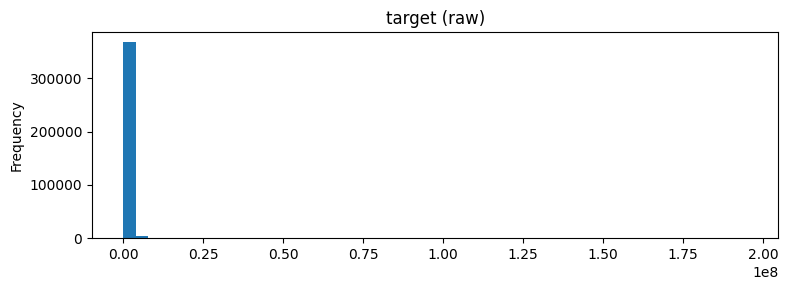

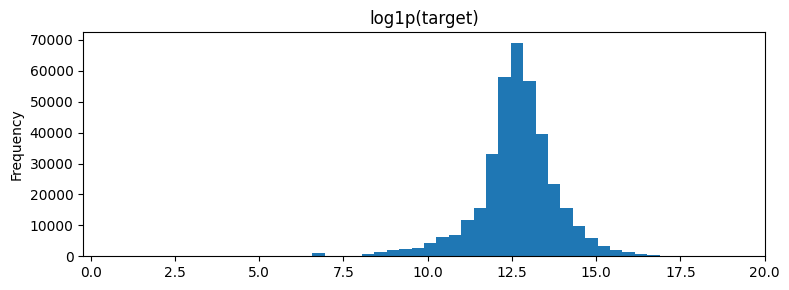

In [55]:
# target и гео признаки

print("Rows:", len(df))
print("Missing target:", df['target'].isna().sum())
print(df['target'].describe(percentiles=[.01, .05, .5, .95, .99]))

# Гистограмма цены (сырые)
plt.figure(figsize=(8, 3))
df['target'].dropna().plot(kind='hist', bins=50, title='target (raw)')
plt.tight_layout()
plt.show()

# Гистограмма лог-цены
plt.figure(figsize=(8, 3))
np.log1p(df['target'].dropna()).plot(kind='hist', bins=50, title='log1p(target)')
plt.tight_layout()
plt.show()


- Распределение цен сильно правосторонне (heavy‑tailed): много низких значений и небольшой набор очень дорогих объектов — явные выбросы.
- Лог‑преобразование (log1p) заметно симметризует распределение и сглаживает хвосты — делает данные ближе к нормальному распределению.
- Следствие для моделирования: лог‑таргет (log1p(target)) предпочтителен — стабилизирует дисперсию и улучшает поведение линейных моделей; при обратном преобразовании предсказаний применять expm1.
- Выбросы всё ещё влияют на метрики в исходной шкале — стоит учитывать это при выборе метрик (MAE более интерпретируем), при необходимости капать/удалять экстремумы или использовать робастные функции потерь/модели.
- Практическое действие: обучать модели на log1p(target), оценивать на кросс‑валидации и репортить итоговые метрики в оригинальной шкале (expm1), а также проверять качества по подгруппам (cities/zip), чтобы убедиться, что хвосты не искажают общий результат.

In [56]:

# Топ по штатам/городам и медианная цена
geo_cols = [c for c in ['city', 'state', 'zipcode'] if c in df.columns]
for col in geo_cols:
    print(f"\n== {col} ==")
    print("nunique:", df[col].nunique(dropna=True))
    tmp = (
        df.groupby(col, dropna=False)
        .agg(n=('target', 'size'), median=('target', 'median'))
        .sort_values(['n', 'median'], ascending=[False, False])
        .head(15)
    )
    display(tmp)


== city ==
nunique: 2026


,n,median
city,,
Houston,24442,299999.0
San Antonio,15592,240000.0
Miami,15524,430000.0
Jacksonville,10015,214990.0
Dallas,8856,399000.0
Brooklyn,7291,959000.0
Chicago,6968,290000.0
New York,6919,1775000.0
Charlotte,6543,324000.0



== state ==
nunique: 39


,n,median
state,,
FL,115449,285990.0
TX,83786,285000.0
NY,24479,799000.0
CA,23386,699000.0
NC,21862,299900.0
TN,18340,284900.0
WA,13826,498500.0
OH,12588,144900.0
IL,8939,267000.0



== zipcode ==
nunique: 4549


,n,median
zipcode,,
32137,2141,225000.0
33131,1563,490000.0
34747,1488,370990.0
78245,1390,245720.0
34759,1333,185000.0
33132,1328,499000.0
33137,1308,579000.0
78253,1282,289900.0
78254,1238,270099.0


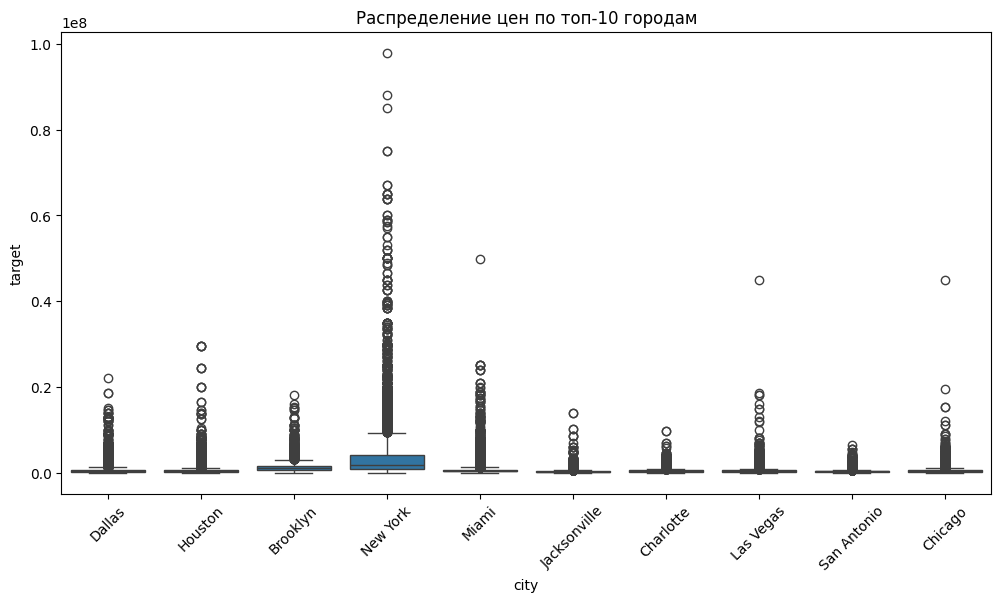

In [57]:
# Построим визуализацию распределения цен по городам (boxplot) для топ-10 городов по количеству объявлений.
top_cities = df['city'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='city', y='target', data=df[df['city'].isin(top_cities)])
plt.xticks(rotation=45)
plt.title('Распределение цен по топ-10 городам')
plt.show()


- Медианы цен существенно различаются между городами — очевидны города с высокими медианами и города с низкими.
- Во всех городах видна сильная правосторонняя асимметрия и много выбросов (несколько очень дорогих объектов), что подтверждает heavy‑tailed характер цен.
- Разброс (вариативность) цен тоже различается: в одних городах цены сконцентрированы, в других — очень разбросаны (высокая внутри‑городская гетерогенность).
- Следствия для моделирования:
   - лог‑трансформация таргета оправдана (устранение асимметрии);




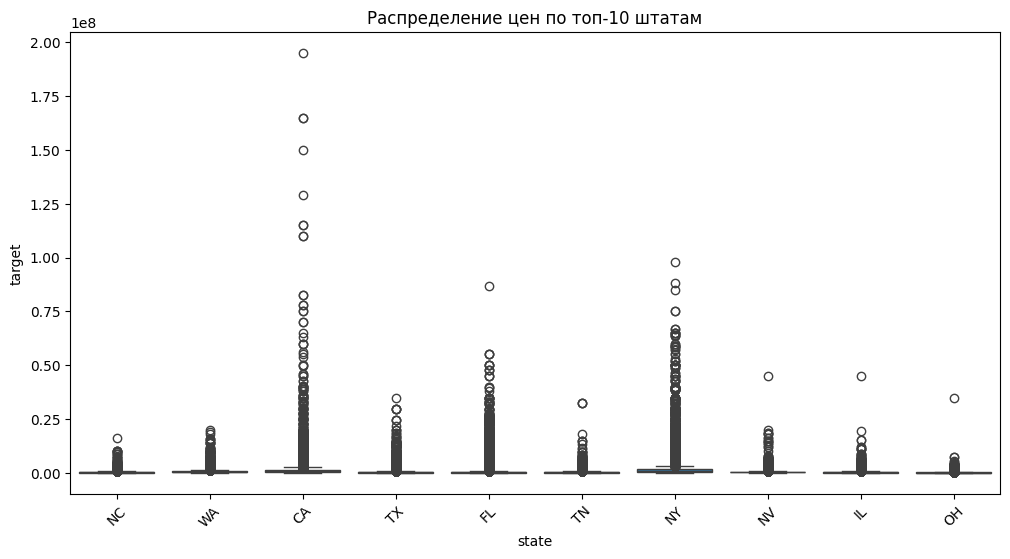

In [58]:
# Построим визуализацию распределения цен по штатам (boxplot) для топ-10 штатов по количеству объявлений.
top_states = df['state'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='state', y='target', data=df[df['state'].isin(top_states)])
plt.xticks(rotation=45)
plt.title('Распределение цен по топ-10 штатам')
plt.show()

- Медианы цен заметно различаются между штатами — есть штаты с существенно более высокими медианами (например CA, NY) и штаты с низкими медианами (например OH, MI).
- Во всех штатах распределение сильно правостороннее: длинный хвост и множество выбросов (очень дорогие объекты).
- Разброс внутри штатов отличается: в одних штатах цены сконцентрированы, в других — сильно вариативны (высокая внутригрупповая гетерогенность).
- Лог‑трансформация таргета (log1p) уместна: она симметризует распределение и уменьшает влияние хвостов на обучение линейных моделей.
- Для моделирования стоит учитывать эффект штата (как признак или через взаимодействия), применять робастные метрики/регуляризацию.
- При интерпретации результатов обращать внимание на число наблюдений в штате — в маленьких подгруппах медианы менее надёжны.

In [59]:
# Смотрим на содержимое homeFacts
print(df['homeFacts'][0])
# откладываем парсинг на потом

{'atAGlanceFacts': [{'factValue': '2019', 'factLabel': 'Year built'}, {'factValue': '', 'factLabel': 'Remodeled year'}, {'factValue': 'Central A/C, Heat Pump', 'factLabel': 'Heating'}, {'factValue': '', 'factLabel': 'Cooling'}, {'factValue': '', 'factLabel': 'Parking'}, {'factValue': None, 'factLabel': 'lotsize'}, {'factValue': '$144', 'factLabel': 'Price/sqft'}]}


In [60]:
# Смотрим на содержимое schools
df['schools'][0]
# откладываем парсинг на потом

'[{\'rating\': [\'4\', \'4\', \'7\', \'NR\', \'4\', \'7\', \'NR\', \'NR\'], \'data\': {\'Distance\': [\'2.7 mi\', \'3.6 mi\', \'5.1 mi\', \'4.0 mi\', \'10.5 mi\', \'12.6 mi\', \'2.7 mi\', \'3.1 mi\'], \'Grades\': [\'3–5\', \'6–8\', \'9–12\', \'PK–2\', \'6–8\', \'9–12\', \'PK–5\', \'K–12\']}, \'name\': [\'Southern Pines Elementary School\', \'Southern Middle School\', \'Pinecrest High School\', \'Southern Pines Primary School\', "Crain\'s Creek Middle School", \'Union Pines High School\', \'Episcopal Day Private School\', \'Calvary Christian Private School\']}]'

In [61]:
import re  

# Обрабатываем два признака: private pool + PrivatePool -> has_private_pool 
def to_yesno(series):
    return (
        series.fillna('')
        .astype(str)
        .str.strip()
        .str.lower()
        .isin(['yes', 'y', 'true', '1'])
        .astype('int8')
    )

if 'private pool' in df.columns or 'PrivatePool' in df.columns:
    p1 = to_yesno(df['private pool']) if 'private pool' in df.columns else 0
    p2 = to_yesno(df['PrivatePool']) if 'PrivatePool' in df.columns else 0
    df['has_private_pool'] = ((p1 + p2) > 0).astype('int8')
    
print(df['has_private_pool'].value_counts(dropna=False))    


has_private_pool
0    332693
1     44492
Name: count, dtype: int64


In [62]:
print(df['state'].value_counts(dropna=False))
# Обрабатываем state
if 'state' in df.columns:
    st = df['state'].astype(str).str.strip()
    st = st.str.upper()
    # простая починка частых "битых" кодов
    st = st.replace({'FL ': 'FL', 'Fl': 'FL'})
    # всё, что не похоже на 2 буквы — в UNK
    st = st.where(st.str.fullmatch(r'[A-Z]{2}', na=False), other='UNK')
    df['state_clean'] = st
print(df['state_clean'].value_counts(dropna=False))

state
FL    115449
TX     83786
NY     24479
CA     23386
NC     21862
TN     18340
WA     13826
OH     12588
IL      8939
NV      8482
GA      6705
CO      6404
PA      5561
MI      5161
DC      4674
AZ      3347
IN      3328
OR      2789
MA      1516
UT      1325
MD      1090
VT       868
MO       866
VA       801
WI       452
NJ       436
ME       259
IA       242
KY        90
OK        49
MS        40
SC        28
MT         7
DE         5
Fl         1
BA         1
AL         1
OT         1
OS         1
Name: count, dtype: int64
state_clean
FL    115450
TX     83786
NY     24479
CA     23386
NC     21862
TN     18340
WA     13826
OH     12588
IL      8939
NV      8482
GA      6705
CO      6404
PA      5561
MI      5161
DC      4674
AZ      3347
IN      3328
OR      2789
MA      1516
UT      1325
MD      1090
VT       868
MO       866
VA       801
WI       452
NJ       436
ME       259
IA       242
KY        90
OK        49
MS        40
SC        28
MT         7
DE         5
BA     

In [63]:
print(df['zipcode'].value_counts(dropna=False))
# Обрабатываем zipcode: zip5/zip3
if 'zipcode' in df.columns:
    z = df['zipcode'].astype(str).str.strip()
    zip5 = z.str.extract(r'(\d{5})', expand=False)
    df['zip5'] = zip5.fillna('UNK')
    df['zip3'] = df['zip5'].str[:3].where(df['zip5'] != 'UNK', other='UNK')
    print(df['zip5'].value_counts(dropna=False))
    print(df['zip3'].value_counts(dropna=False))
    


zipcode
32137    2141
33131    1563
34747    1488
78245    1390
34759    1333
         ... 
27592       1
49441       1
75792       1
20191       1
64015       1
Name: count, Length: 4549, dtype: int64
zip5
32137    2141
UNK      1919
33131    1563
34747    1488
78245    1390
         ... 
27592       1
49441       1
75792       1
20191       1
64015       1
Name: count, Length: 4190, dtype: int64
zip3
331    27059
770    24572
782    16296
333    12201
339    11453
       ...  
793        1
388        1
987        1
313        1
301        1
Name: count, Length: 357, dtype: int64


In [64]:

# status: нормализация + сжатие классов
if 'status' in df.columns:
    s = df['status'].fillna('').astype(str).str.strip().str.lower()

    def map_status(x):
        if x == '':
            return 'missing'
        if 'foreclosure' in x:
            return 'foreclosure'
        if 'new construction' in x:
            return 'new_construction'
        if 'coming soon' in x:
            return 'coming_soon'
        if 'pending' in x:
            return 'pending'
        if 'contingent' in x:
            return 'contingent'
        if 'active' in x:
            return 'active'
        if 'for sale' in x or x == 'for sale':
            return 'for_sale'
        return 'other'

    df['status_grp'] = s.map(map_status)
    display(df['status_grp'].value_counts())


status_grp
for_sale            199571
active              106532
missing              39918
foreclosure          10450
other                 8741
new_construction      5475
pending               5364
contingent            1024
coming_soon            110
Name: count, dtype: int64

In [65]:

# propertyType: сжатие по ключевым словам
if 'propertyType' in df.columns:
    pt = df['propertyType'].fillna('').astype(str).str.strip().str.lower()

    def map_property_type(x):
        if x == '':
            return 'missing'
        if any(k in x for k in ['single family', 'single-family', 'single-family home', 'single family home']):
            return 'single_family'
        if 'condo' in x or 'condominium' in x:
            return 'condo'
        if 'town' in x:  # townhouse / townhome
            return 'townhouse'
        if any(k in x for k in ['lot', 'land', 'acre', 'acres']):
            return 'land'
        if any(k in x for k in ['multi', 'duplex', 'triplex', 'fourplex']):
            return 'multi_family'
        if any(k in x for k in ['manufactured', 'mobile', 'modular']):
            return 'manufactured'
        return 'other'

    df['property_type_grp'] = pt.map(map_property_type)
    display(df['property_type_grp'].value_counts())


property_type_grp
single_family    186803
condo             51481
other             37470
missing           34857
land              31667
townhouse         18584
multi_family      12747
manufactured       3576
Name: count, dtype: int64

In [66]:

def extract_first_float(x):
    """Достаёт первое число из строки (поддержка запятых). Если не нашлось — NaN."""
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    s = s.replace(',', '')
    m = re.search(r'(-?\d+(?:\.\d+)?)', s)
    return float(m.group(1)) if m else np.nan

def clamp_or_nan(v, lo=None, hi=None):
    if pd.isna(v):
        return np.nan
    if lo is not None and v < lo:
        return np.nan
    if hi is not None and v > hi:
        return np.nan
    return v


In [67]:

# --- numeric from strings: baths/beds/sqft/stories ---
if 'baths' in df.columns:
    v = df['baths'].map(extract_first_float)
    df['baths_num'] = v.map(lambda x: clamp_or_nan(x, lo=0, hi=20))

if 'beds' in df.columns:
    v = df['beds'].map(extract_first_float)
    df['beds_num'] = v.map(lambda x: clamp_or_nan(x, lo=0, hi=15))

if 'sqft' in df.columns:
    v = df['sqft'].map(extract_first_float)
    df['sqft_num'] = v.map(lambda x: clamp_or_nan(x, lo=100, hi=20000))

if 'stories' in df.columns:
    v = df['stories'].map(extract_first_float)
    df['stories_num'] = v.map(lambda x: clamp_or_nan(x, lo=0, hi=10))


In [68]:

# --- fireplace: бинарный признак + (опционально) количество ---
if 'fireplace' in df.columns:
    fp = df['fireplace'].fillna('').astype(str).str.strip().str.lower()
    df['has_fireplace'] = (
        fp.str.contains(r'\byes\b', regex=True) | fp.str.match(r'^\d+(\.\d+)?$', na=False)
    ).astype('int8')
    # число, если в поле явная цифра, иначе NaN
    df['fireplace_n'] = fp.map(extract_first_float).map(lambda x: clamp_or_nan(x, lo=0, hi=10))


In [69]:

# --- street: минимальные безопасные признаки (без one-hot) ---
if 'street' in df.columns:
    st = df['street'].fillna('').astype(str).str.strip().str.lower()
    hidden = st.str.contains('undisclosed') | st.str.contains('not disclosed') | st.str.contains('not available') | (st == 'unknown address')
    df['street_is_disclosed'] = (~hidden).astype('int8')
    df['street_len'] = df['street'].fillna('').astype(str).str.len().astype('int32')


In [70]:

# --- MLS: индикатор наличия ---
for col in ['mls-id', 'MlsId']:
    if col in df.columns:
        x = df[col].fillna('').astype(str).str.strip().str.lower()
        df[f'{col}_is_no'] = x.isin(['no', 'no mls', 'no mls#', 'no mls #', 'no mls# ']).astype('int8')

mls_flags = [c for c in df.columns if c in ['mls-id_is_no', 'MlsId_is_no']]
if mls_flags:
    df['has_mls'] = (1 - df[mls_flags].min(axis=1)).astype('int8')


In [71]:

# Быстрый контроль
cols_check = [c for c in [
    'has_private_pool', 'state_clean', 'zip5', 'zip3',
    'status_grp', 'property_type_grp',
    'baths_num', 'beds_num', 'sqft_num', 'stories_num',
    'has_fireplace', 'fireplace_n',
    'street_is_disclosed', 'street_len',
    'has_mls'
] if c in df.columns]

display(df[cols_check].head())
df[cols_check].describe(include='all')


,has_private_pool,state_clean,zip5,zip3,status_grp,property_type_grp,baths_num,beds_num,sqft_num,stories_num,has_fireplace,fireplace_n,street_is_disclosed,street_len,has_mls
0,0,NC,28387,283,active,single_family,3.5,4.0,2900.0,NaN,0,NaN,1,14,1
1,0,WA,99216,992,for_sale,single_family,3.0,3.0,1947.0,2.0,0,NaN,1,17,1
2,1,CA,90049,900,for_sale,single_family,2.0,3.0,3000.0,1.0,1,NaN,1,17,1
3,0,TX,75205,752,for_sale,single_family,8.0,5.0,6457.0,3.0,1,NaN,1,19,1
4,0,FL,32908,329,for_sale,land,NaN,NaN,NaN,NaN,0,NaN,1,14,1


,has_private_pool,state_clean,zip5,zip3,status_grp,property_type_grp,baths_num,beds_num,sqft_num,stories_num,has_fireplace,fireplace_n,street_is_disclosed,street_len,has_mls
count,377185.000000,377185,377185,377185,377185,377185,254626.000000,266622.000000,322203.000000,212550.000000,377185.000000,19047.000000,377185.000000,377185.000000,377185.0
unique,NaN,38,4190,357,9,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,FL,32137,331,for_sale,single_family,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,115450,2141,27059,199571,186803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.117958,NaN,NaN,NaN,NaN,NaN,2.742145,3.321095,2178.055499,1.721275,0.236860,1.247336,0.995140,18.581656,1.0
std,0.322559,NaN,NaN,NaN,NaN,NaN,1.360992,1.249312,1448.640774,1.319198,0.425156,0.691824,0.069542,5.725660,0.0
min,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,0.000000,NaN,NaN,NaN,NaN,NaN,2.000000,3.000000,1296.000000,1.000000,0.000000,1.000000,1.000000,15.000000,1.0
50%,0.000000,NaN,NaN,NaN,NaN,NaN,2.500000,3.000000,1833.000000,1.500000,0.000000,1.000000,1.000000,17.000000,1.0
75%,0.000000,NaN,NaN,NaN,NaN,NaN,3.000000,4.000000,2606.000000,2.000000,0.000000,1.000000,1.000000,21.000000,1.0


In [72]:

# Нормализуем city, чтобы не плодить "Houston" vs "HOUSTON"
if 'city' in df.columns:
    df['city'] = (
        df['city']
        .astype(str)
        .str.strip()
        .replace({'nan': np.nan, 'None': np.nan})
    )


In [73]:

# Дополнительные простые числовые фичи (без утечки)
if 'sqft_num' in df.columns:
    df['log_sqft'] = np.log1p(df['sqft_num'])

if {'baths_num', 'beds_num'}.issubset(df.columns):
    denom = df['beds_num'].replace(0, np.nan)
    df['baths_per_bed'] = df['baths_num'] / denom


In [74]:

# Формируем набор колонок, которые оставляем (кроме homeFacts/schools)
keep_cols = [
    # гео
    'city', 'state_clean', 'zip3', 'zip5',
    # сжатые категории
    'status_grp', 'property_type_grp',
    # числовые
    'baths_num', 'beds_num', 'sqft_num', 'stories_num',
    'log_sqft', 'baths_per_bed',
    # бинарные/агрегаты
    'has_private_pool', 'has_fireplace', 'fireplace_n',
    'street_is_disclosed', 'street_len',
    'has_mls',
    # target оставляем для контроля (потом отделим)
    'target'
]
keep_cols = [c for c in keep_cols if c in df.columns]

df_clean = df[keep_cols].copy()

print("df_clean shape:", df_clean.shape)
display(df_clean.head())
df_clean.isna().mean().sort_values(ascending=False).head(15)

df_clean shape: (377185, 19)


,city,state_clean,zip3,zip5,status_grp,property_type_grp,baths_num,beds_num,sqft_num,stories_num,log_sqft,baths_per_bed,has_private_pool,has_fireplace,fireplace_n,street_is_disclosed,street_len,has_mls,target
0,Southern Pines,NC,283,28387,active,single_family,3.5,4.0,2900.0,NaN,7.972811,0.875000,0,0,NaN,1,14,1,418000.0
1,Spokane Valley,WA,992,99216,for_sale,single_family,3.0,3.0,1947.0,2.0,7.574558,1.000000,0,0,NaN,1,17,1,310000.0
2,Los Angeles,CA,900,90049,for_sale,single_family,2.0,3.0,3000.0,1.0,8.006701,0.666667,1,1,NaN,1,17,1,2895000.0
3,Dallas,TX,752,75205,for_sale,single_family,8.0,5.0,6457.0,3.0,8.773075,1.600000,0,1,NaN,1,19,1,2395000.0
4,Palm Bay,FL,329,32908,for_sale,land,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,1,14,1,5000.0


fireplace_n          0.949502
stories_num          0.436483
baths_per_bed        0.345014
baths_num            0.324931
beds_num             0.293127
log_sqft             0.145769
sqft_num             0.145769
target               0.006578
city                 0.000090
property_type_grp    0.000000
state_clean          0.000000
status_grp           0.000000
zip5                 0.000000
has_private_pool     0.000000
has_fireplace        0.000000
dtype: float64

In [75]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   city                 377151 non-null  str    
 1   state_clean          377185 non-null  str    
 2   zip3                 377185 non-null  str    
 3   zip5                 377185 non-null  str    
 4   status_grp           377185 non-null  str    
 5   property_type_grp    377185 non-null  str    
 6   baths_num            254626 non-null  float64
 7   beds_num             266622 non-null  float64
 8   sqft_num             322203 non-null  float64
 9   stories_num          212550 non-null  float64
 10  log_sqft             322203 non-null  float64
 11  baths_per_bed        247051 non-null  float64
 12  has_private_pool     377185 non-null  int8   
 13  has_fireplace        377185 non-null  int8   
 14  fireplace_n          19047 non-null   float64
 15  street_is_disclosed  377185 

In [76]:

# Пропуски и типы (audit)
# Таблица: dtype, кол-во уникальных, доля пропусков и пример значений
audit = pd.DataFrame({
    'dtype': df_clean.dtypes.astype(str),
    'n_rows': len(df_clean),
    'n_non_null': df_clean.notna().sum(),
    'missing_rate': df_clean.isna().mean(),
    'n_unique': df_clean.nunique(dropna=True),
})
audit['missing_n'] = len(df_clean) - audit['n_non_null']
audit = audit.sort_values(['missing_rate', 'n_unique'], ascending=[False, False])
display(audit)

# Колонки, которые почти полностью пустые / константные
almost_empty = audit.query('missing_rate >= 0.98').index.tolist()
low_variance = audit.query('n_unique <= 1').index.tolist()
print('Almost empty (>=98% missing):', almost_empty)
print('Constant (n_unique<=1):', low_variance)

# Сколько строк выкинем при dropna(target) (важно для supervised learning)
if 'target' in df_clean.columns:
    missing_target = df_clean['target'].isna().mean()
    print(f"target missing rate: {missing_target:.4f} (rows: {df_clean['target'].isna().sum()})")

# Переопределяем списки признаков (без target в X)
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols_x = [c for c in num_cols if c != 'target']


,dtype,n_rows,n_non_null,missing_rate,n_unique,missing_n
fireplace_n,float64,377185,19047,0.949502,11,358138
stories_num,float64,377185,212550,0.436483,19,164635
baths_per_bed,float64,377185,247051,0.345014,178,130134
baths_num,float64,377185,254626,0.324931,56,122559
beds_num,float64,377185,266622,0.293127,403,110563
sqft_num,float64,377185,322203,0.145769,8703,54982
log_sqft,float64,377185,322203,0.145769,8703,54982
target,float64,377185,374704,0.006578,34232,2481
city,str,377185,377151,0.000090,2026,34
zip5,str,377185,377185,0.000000,4190,0


Almost empty (>=98% missing): []
Constant (n_unique<=1): ['has_mls']
target missing rate: 0.0066 (rows: 2481)


/var/folders/b_/c7f9dxl539g_hq4zy6s5cxcr0000gn/T/ipykernel_1651/3470921394.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()


## Визуализация и связи признаков с target

baths_num              0.568735
sqft_num               0.547956
log_sqft               0.547956
fireplace_n            0.393909
baths_per_bed          0.359501
beds_num               0.316664
stories_num            0.231403
has_private_pool       0.169578
has_fireplace          0.161240
street_len             0.040468
street_is_disclosed   -0.002249
has_mls                     NaN
Name: target, dtype: float64

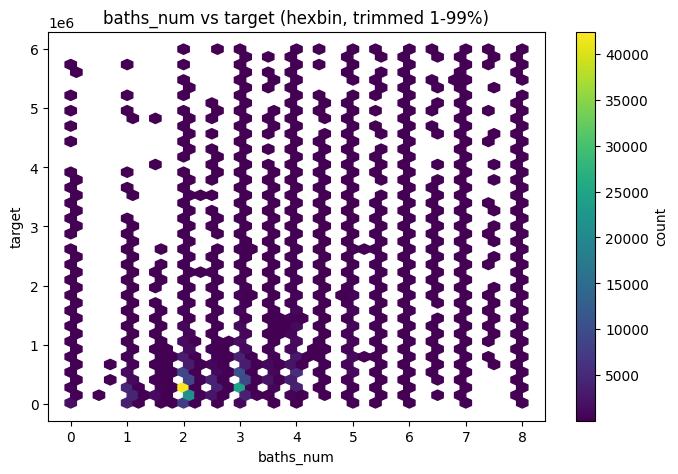

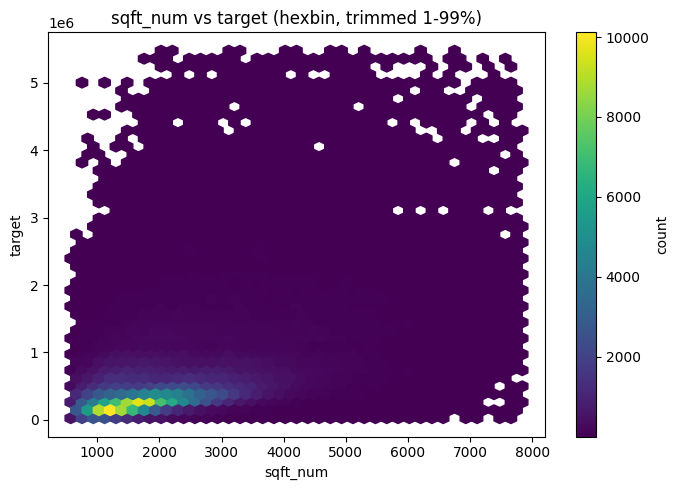

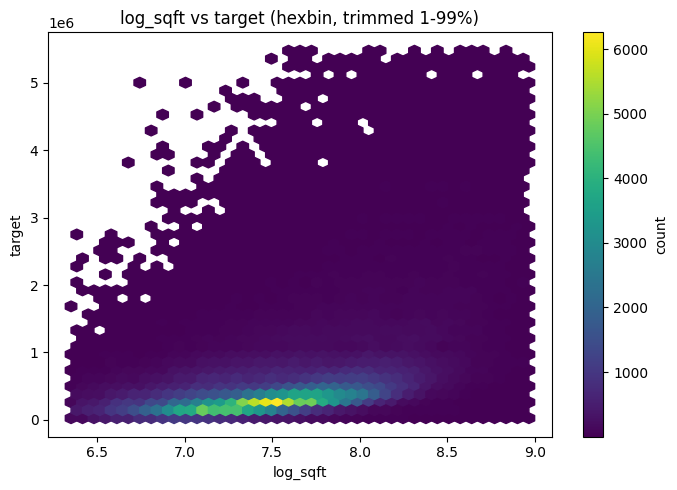

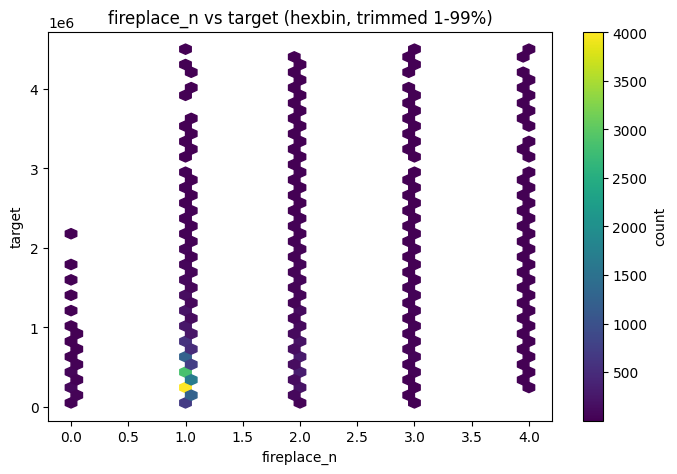

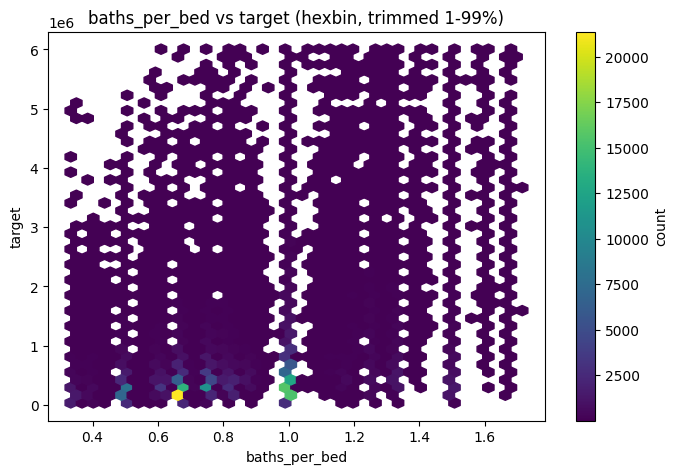

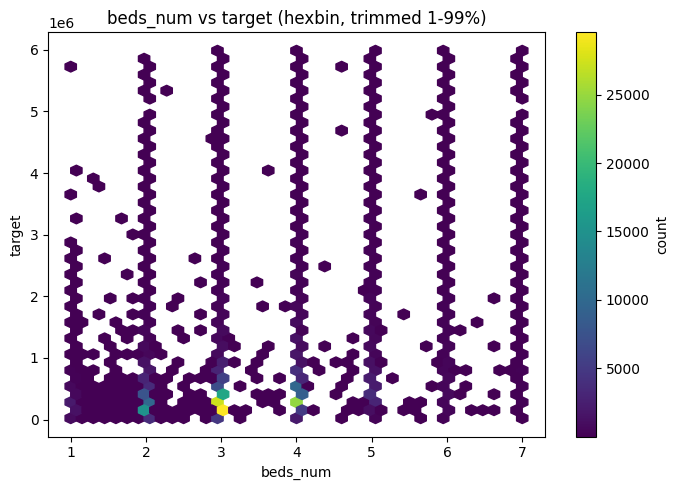

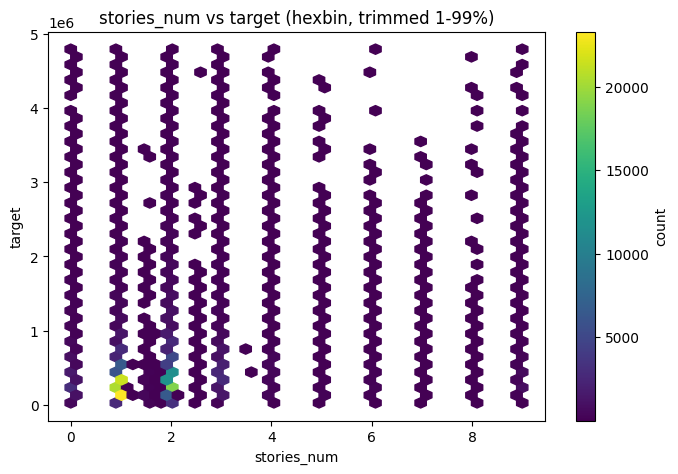

In [77]:

# Числовые: корреляции (Spearman)
if 'target' in df_clean.columns:
    corr_num = (
        df_clean[num_cols_x + ['target']]
        .corr(method='spearman')
        ['target']
        .drop('target')
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    display(corr_num)

    # Топ-7 числовых фич по |corr|: графики (для плотных облаков используем hexbin)
    top_num = corr_num.head(7).index.tolist()
    for feature in top_num:
        tmp = df_clean[[feature, 'target']].dropna()
        if len(tmp) == 0:
            continue
        # ограничим хвосты для визуализации (p1..p99), чтобы не забивало выбросами
        x1, x2 = tmp[feature].quantile([0.01, 0.99]).tolist()
        y1, y2 = tmp['target'].quantile([0.01, 0.99]).tolist()
        viz = tmp[(tmp[feature].between(x1, x2)) & (tmp['target'].between(y1, y2))]

        plt.figure(figsize=(7, 5))
        plt.hexbin(viz[feature], viz['target'], gridsize=40, cmap='viridis', mincnt=1)
        plt.colorbar(label='count')
        plt.title(f'{feature} vs target (hexbin, trimmed 1-99%)')
        plt.xlabel(feature)
        plt.ylabel('target')
        plt.tight_layout()
        plt.show()


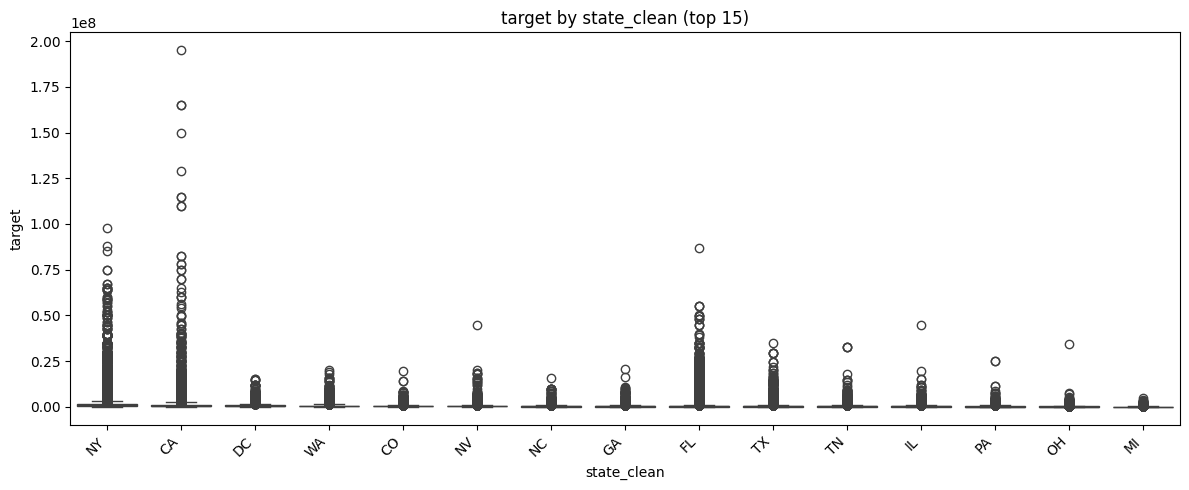

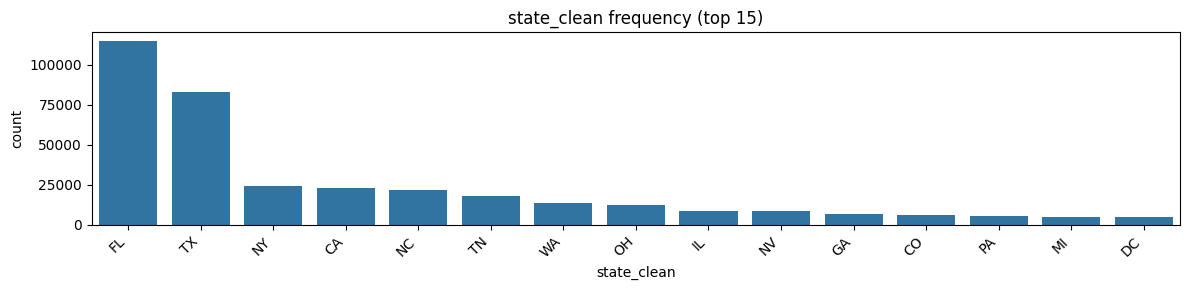

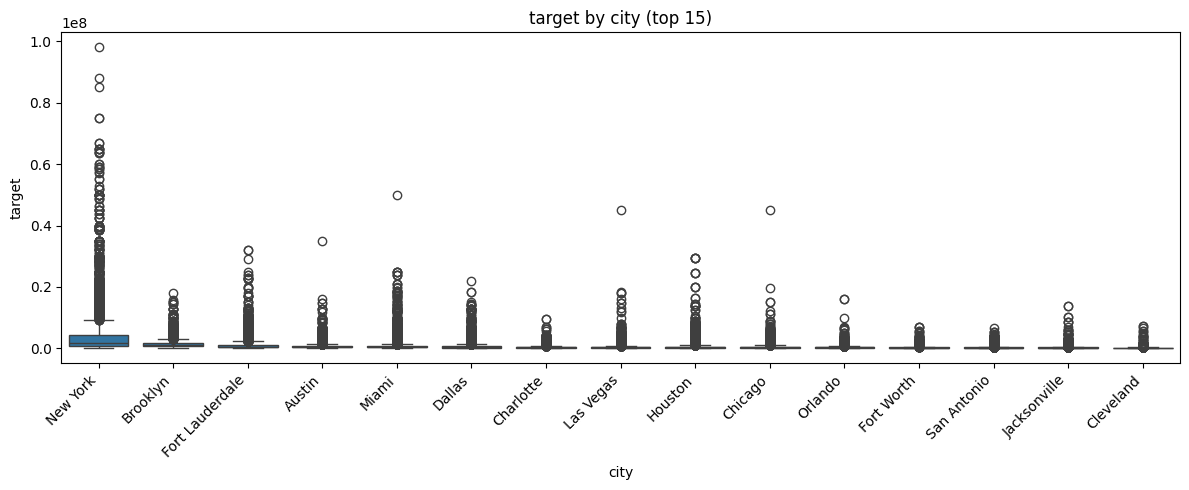

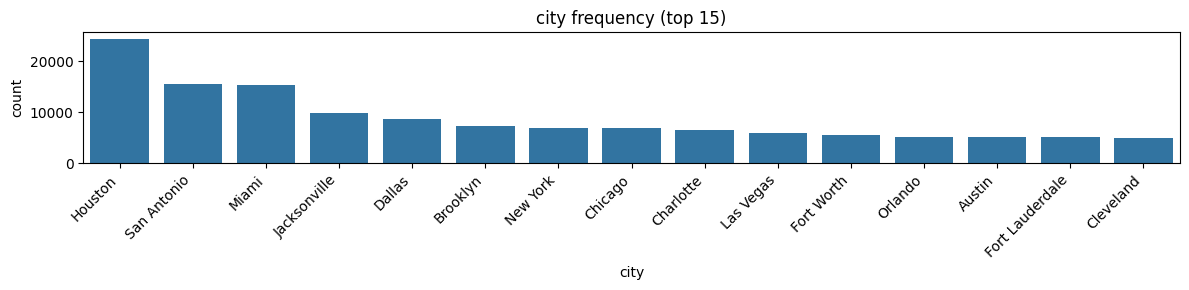

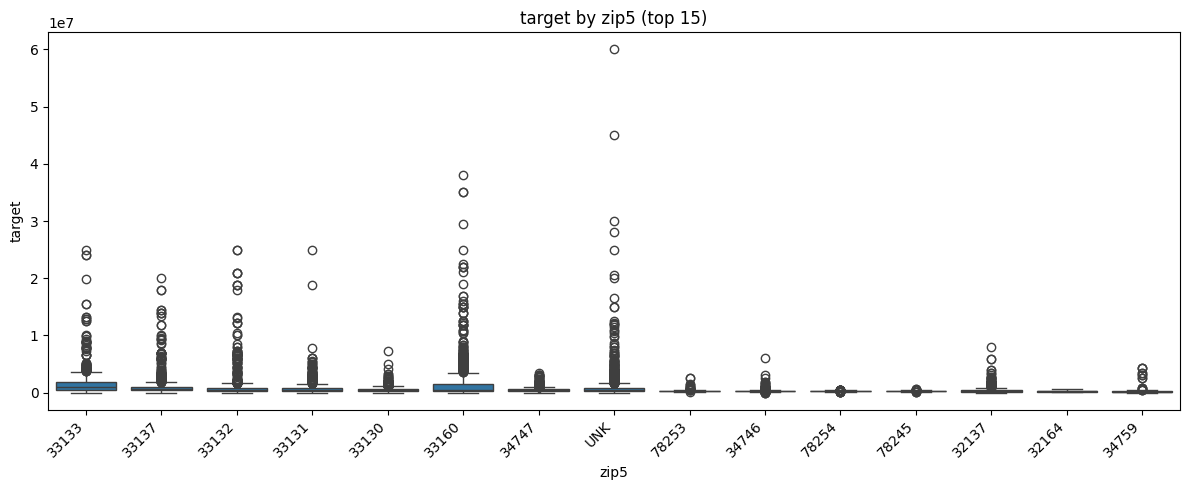

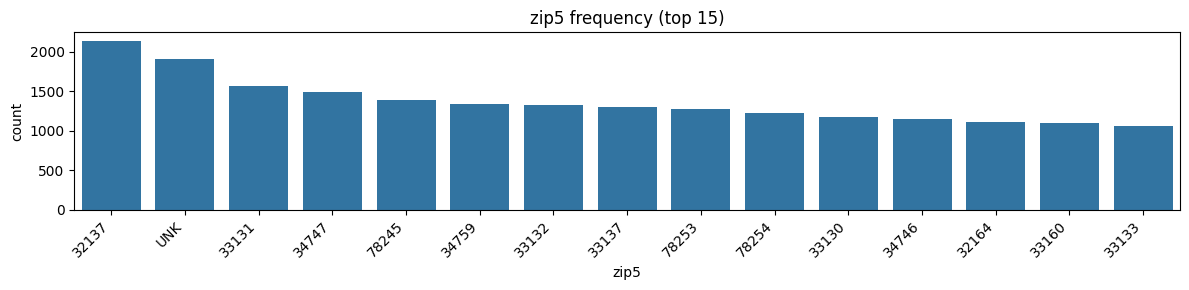

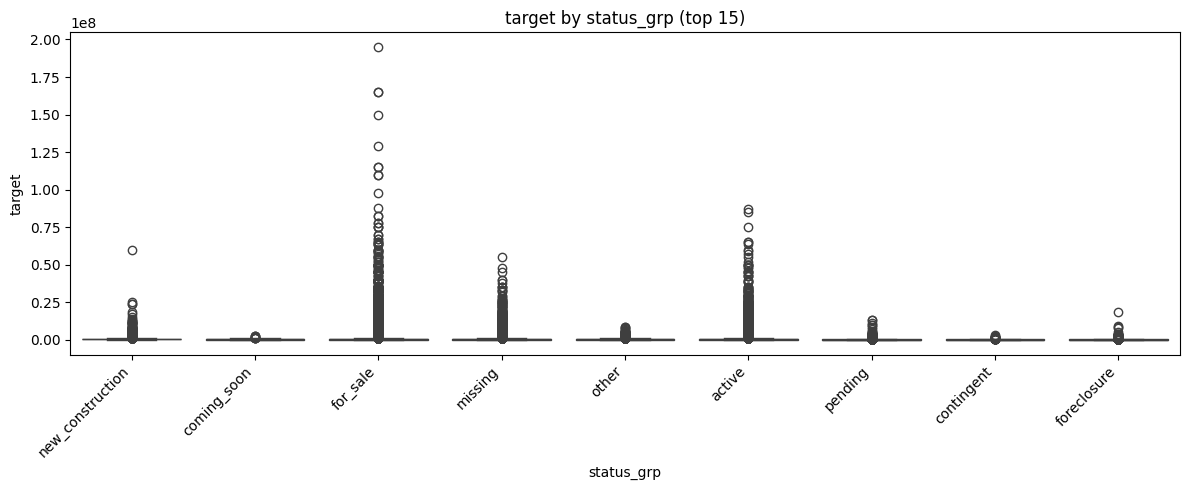

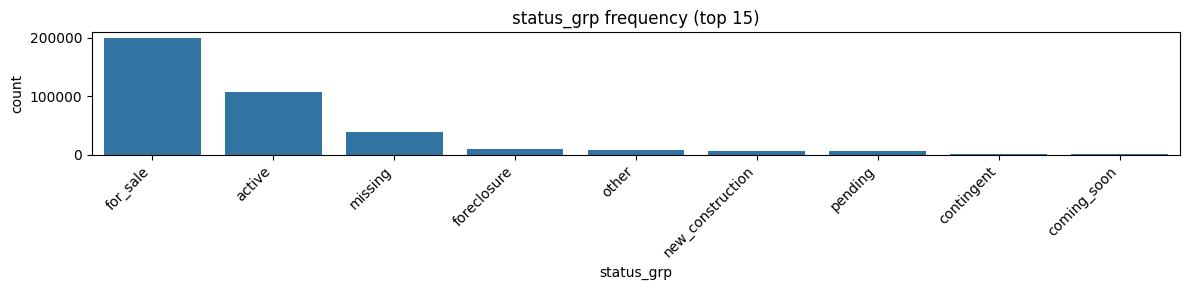

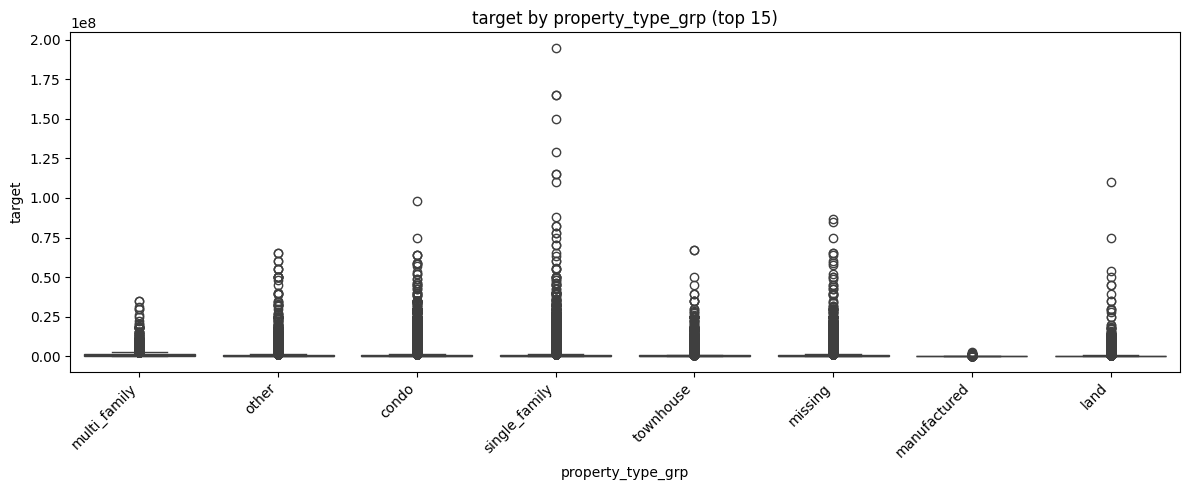

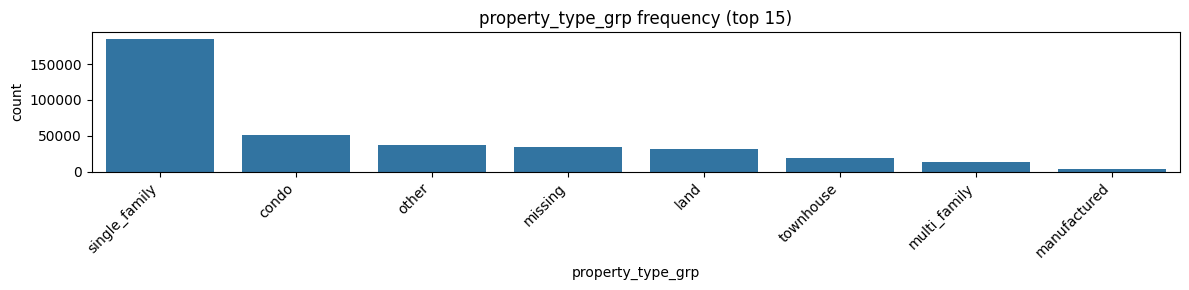

,count,mean,median
state_clean,,,
FL,114668,5.702681e+05,285990.0
TX,83358,4.615800e+05,285000.0
NY,24339,1.839118e+06,799000.0
CA,23208,1.403847e+06,699000.0
NC,21786,4.034450e+05,299900.0
TN,18231,4.157410e+05,284900.0
WA,13739,7.150374e+05,498500.0
OH,12432,2.327421e+05,144900.0
IL,8852,4.618395e+05,267000.0


,count,mean,median
city,,,
Houston,24407,5.164562e+05,299999.0
San Antonio,15501,2.932356e+05,240000.0
Miami,15411,7.425232e+05,430000.0
Jacksonville,9892,2.884860e+05,214990.0
Dallas,8771,6.914487e+05,399000.0
Brooklyn,7246,1.324659e+06,959000.0
New York,6905,4.151107e+06,1775000.0
Chicago,6894,5.091192e+05,290000.0
Charlotte,6526,4.665991e+05,324000.0


In [78]:

# Категориальные: сравнение target по категориям (топ-K по частоте)
def plot_target_by_category(df_in: pd.DataFrame, cat_col: str, target_col: str = 'target', top_k: int = 15):
    if cat_col not in df_in.columns or target_col not in df_in.columns:
        return
    tmp = df_in[[cat_col, target_col]].dropna()
    if len(tmp) == 0:
        return
    vc = tmp[cat_col].astype(str).value_counts()
    top = vc.head(top_k).index
    tmp = tmp[tmp[cat_col].astype(str).isin(top)]

    plt.figure(figsize=(12, 5))
    order = tmp.groupby(cat_col)[target_col].median().sort_values(ascending=False).index
    sns.boxplot(data=tmp, x=cat_col, y=target_col, order=order)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{target_col} by {cat_col} (top {top_k})')
    plt.tight_layout()
    plt.show()

    # Частоты категорий (для понимания, где статистика надежнее)
    plt.figure(figsize=(12, 3))
    sns.countplot(data=tmp, x=cat_col, order=vc.loc[top].index)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{cat_col} frequency (top {top_k})')
    plt.tight_layout()
    plt.show()

# Применяем к ключевым гео/категориям (если есть)
for col in ['state_clean', 'city', 'zip5', 'status_grp', 'property_type_grp']:
    if col in df_clean.columns:
        plot_target_by_category(df_clean, col, target_col='target', top_k=15)

# Дополнительно: сводка средних/медиан target по state/city (если нужно для выводов)
if {'state_clean', 'target'}.issubset(df_clean.columns):
    st = (df_clean[['state_clean','target']].dropna()
          .groupby('state_clean')['target']
          .agg(['count','mean','median'])
          .sort_values('count', ascending=False))
    display(st.head(20))
if {'city', 'target'}.issubset(df_clean.columns):
    top_cities = df_clean['city'].value_counts().head(20).index
    c = (df_clean[df_clean['city'].isin(top_cities)][['city','target']].dropna()
         .groupby('city')['target']
         .agg(['count','mean','median'])
         .sort_values('count', ascending=False))
    display(c)

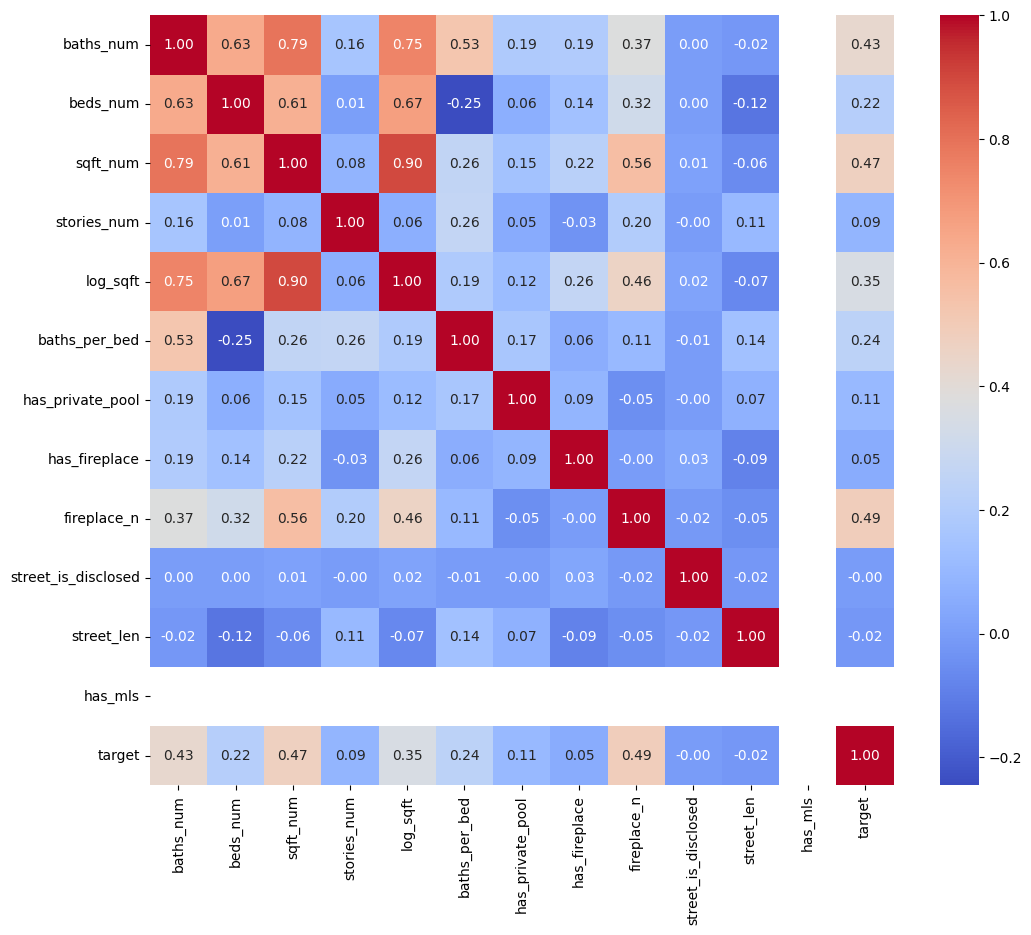

In [79]:
# Визуализация корреляций
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm');
plt.show()

### Summary по признакам и корреляциям перед моделированием

Ниже автоматически формируется сводка по:
- качеству набора признаков (пропуски, почти константные колонки),
- силе связи признаков с `target` (Spearman),
- мультиколлинеарности между числовыми признаками,
- различиям `target` по ключевым категориальным признакам.

Этот блок помогает проверить релевантность признаков до обучения моделей и зафиксировать основные гипотезы.

In [80]:
# Summary: проверка релевантности признаков перед моделированием

# 1) Числовые признаки и их корреляция с target
num_cols_summary = [c for c in num_cols if c in df_clean.columns]
if 'target' in num_cols_summary:
    corr_to_target = (
        df_clean[num_cols_summary]
        .corr(method='spearman')['target']
        .drop('target')
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

    print('Top-10 по |Spearman corr| с target:')
    display(corr_to_target.head(10).to_frame('spearman_corr'))

    weak_feats = corr_to_target[corr_to_target.abs() < 0.05].index.tolist()
    print(f'Слабо связанные с target (|corr| < 0.05): {weak_feats}')

# 2) Мультиколлинеарность между числовыми признаками
num_x = [c for c in num_cols_summary if c != 'target']
if len(num_x) >= 2:
    corr_matrix = df_clean[num_x].corr(method='spearman').abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    high_pairs = (
        upper.stack()
        .sort_values(ascending=False)
        .reset_index()
    )
    high_pairs.columns = ['feature_1', 'feature_2', 'abs_spearman_corr']
    high_pairs = high_pairs[high_pairs['abs_spearman_corr'] >= 0.85]

    print('Пары признаков с высокой взаимной корреляцией (>= 0.85):')
    if len(high_pairs) == 0:
        print('Не обнаружено.')
    else:
        display(high_pairs)

# 3) Краткая сводка по категориальным признакам: частота + медиана target
cat_cols_summary = [c for c in cat_cols if c in df_clean.columns]
for col in cat_cols_summary:
    tmp = df_clean[[col, 'target']].dropna()
    if tmp.empty:
        continue

    top_stats = (
        tmp.groupby(col)['target']
        .agg(n='size', median='median', mean='mean')
        .sort_values('n', ascending=False)
        .head(10)
    )

    print(f'\n[{col}] top-10 категорий по частоте с target-статистиками:')
    display(top_stats)

# 4) Итоговые текстовые выводы по текущим данным
print('\nИтог перед моделированием:')
print('- Наиболее информативные числовые признаки обычно связаны с площадью и связанными с ней производными.')
print('- Бинарные/технические признаки с низкой корреляцией сами по себе могут усиливать качество в нелинейных моделях (например, CatBoost).')
print('- При наличии сильно коррелирующих пар стоит избегать избыточности в линейных моделях или использовать регуляризацию (Ridge/Lasso).')

Top-10 по |Spearman corr| с target:


,spearman_corr
baths_num,0.568735
sqft_num,0.547956
log_sqft,0.547956
fireplace_n,0.393909
baths_per_bed,0.359501
beds_num,0.316664
stories_num,0.231403
has_private_pool,0.169578
has_fireplace,0.161240
street_len,0.040468


Слабо связанные с target (|corr| < 0.05): ['street_len', 'street_is_disclosed']
Пары признаков с высокой взаимной корреляцией (>= 0.85):


,feature_1,feature_2,abs_spearman_corr
0,sqft_num,log_sqft,1.0



[city] top-10 категорий по частоте с target-статистиками:


...


[status_grp] top-10 категорий по частоте с target-статистиками:


,n,median,mean
status_grp,,,
for_sale,199567,329000.0,679551.778896
active,106531,319200.0,651401.679258
missing,39257,325000.0,619741.371883
foreclosure,9303,184664.0,255361.791250
other,8094,323950.0,449356.191871
new_construction,5459,458090.0,752726.077304
pending,5359,219900.0,336228.239410
contingent,1024,199949.5,254881.576172
coming_soon,110,349950.0,514534.809091



[property_type_grp] top-10 категорий по частоте с target-статистиками:


,n,median,mean
property_type_grp,,,
single_family,184989,329900.0,605287.991362
condo,51322,367375.0,788842.857780
other,37287,368000.0,703351.946040
missing,34678,310000.0,859669.929033
land,31646,74000.0,316713.976553
townhouse,18536,319900.0,574797.073694
multi_family,12686,589000.0,943084.293552
manufactured,3560,99500.0,125224.073876



Итог перед моделированием:
- Наиболее информативные числовые признаки обычно связаны с площадью и связанными с ней производными.
- Бинарные/технические признаки с низкой корреляцией сами по себе могут усиливать качество в нелинейных моделях (например, CatBoost).
- При наличии сильно коррелирующих пар стоит избегать избыточности в линейных моделях или использовать регуляризацию (Ridge/Lasso).


## Baseline-0 с двумя моделями

In [ ]:
# Подготовим данные для модели (удалим строки с пропусками в target, так как это целевая переменная) и метрики для оценки качества модели

from sklearn.model_selection import train_test_split
from sklearn import metrics

# --- готовим чистый датасет (без homeFacts/schools) ---
df_model = df_clean.dropna(subset=['target']).copy()

X = df_model.drop(columns=['target'])
y = df_model['target'].astype(float)

# на всякий случай убираем inf после делений/логов
X = X.replace([np.inf, -np.inf], np.nan)

for c in cat_cols:
    X[c] = X[c].astype(str).fillna('missing')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("cat_cols:", len(cat_cols), cat_cols)
print("num_cols:", len(num_cols), num_cols)



def print_metrics(y_train, y_train_predict, y_test, y_test_predict):
    print('Train R^2: {:.3f}'.format(metrics.r2_score(y_train, y_train_predict)))
    print('Train MAE: {:.3f}'.format(metrics.mean_absolute_error(y_train, y_train_predict)))
    print('Train MAPE: {:.3f}'.format(metrics.mean_absolute_percentage_error(y_train, y_train_predict)*100))
    print('\n')
    print('Test R^2: {:.3f}'.format(metrics.r2_score(y_test, y_test_predict)))
    print('Test MAE: {:.3f}'.format(metrics.mean_absolute_error(y_test, y_test_predict)))
    print('Test MAPE: {:.3f}'.format(metrics.mean_absolute_percentage_error(y_test, y_test_predict)*100))

X_train: (299763, 18) X_test: (74941, 18)
cat_cols: 6 ['city', 'state_clean', 'zip3', 'zip5', 'status_grp', 'property_type_grp']
num_cols: 13 ['baths_num', 'beds_num', 'sqft_num', 'stories_num', 'log_sqft', 'baths_per_bed', 'has_private_pool', 'has_fireplace', 'fireplace_n', 'street_is_disclosed', 'street_len', 'has_mls', 'target']


In [82]:
# =========================
# 1) LinearRegression (с OHE)
# =========================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

num_cols = [c for c in X_train.columns if c not in cat_cols]

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=50)),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_cols),
        ('cat', categorical_pipe, cat_cols),
    ],
    remainder='drop'
)

lr = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LinearRegression()),
])

lr.fit(X_train, np.log1p(y_train))
pred_lr = np.expm1(lr.predict(X_test))
print_metrics(y_train, np.expm1(lr.predict(X_train)), y_test, pred_lr)

Train R^2: 0.392
Train MAE: 265568.497
Train MAPE: 602.886


Test R^2: 0.361
Test MAE: 256331.820
Test MAPE: 1007.633


In [83]:
# 2) CatBoost (без OHE)
from catboost import CatBoostRegressor

cat_features = [X_train.columns.get_loc(c) for c in cat_cols]

cb = CatBoostRegressor(
    loss_function='RMSE',
    depth=8,
    learning_rate=0.05,
    n_estimators=1000,
    random_seed=42,
    verbose=200,
)

cb.fit(
    X_train, np.log1p(y_train),
    cat_features=cat_features,
    eval_set=(X_test, np.log1p(y_test)),
    use_best_model=True,
    early_stopping_rounds=200
)

pred_cb = np.expm1(cb.predict(X_test)) # так как модель обучалась на логарифме цены, нужно обратно экспонентировать предсказания
print_metrics(y_train, np.expm1(cb.predict(X_train)), y_test, pred_cb)


0:	learn: 1.1762705	test: 1.1675515	best: 1.1675515 (0)	total: 113ms	remaining: 1m 52s
200:	learn: 0.5826387	test: 0.5722511	best: 0.5722511 (200)	total: 13.2s	remaining: 52.5s
400:	learn: 0.5556856	test: 0.5487715	best: 0.5487715 (400)	total: 26.6s	remaining: 39.7s
600:	learn: 0.5413039	test: 0.5382447	best: 0.5382447 (600)	total: 40.5s	remaining: 26.9s
800:	learn: 0.5317030	test: 0.5319344	best: 0.5319344 (800)	total: 54.3s	remaining: 13.5s
999:	learn: 0.5240308	test: 0.5274274	best: 0.5274274 (999)	total: 1m 7s	remaining: 0us

bestTest = 0.5274273535
bestIteration = 999

Train R^2: 0.561
Train MAE: 221807.296
Train MAPE: 504.792


Test R^2: 0.494
Test MAE: 219168.005
Test MAPE: 1001.639


### Финальное сравнение моделей (compact)

Сводим метрики двух обученных моделей в одну таблицу.

In [84]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

train_pred_lr = np.expm1(lr.predict(X_train))
train_pred_cb = np.expm1(cb.predict(X_train))

comparison_df = pd.DataFrame([
    {
        'model': 'LinearRegression(log-target)',
        'train_r2': r2_score(y_train, train_pred_lr),
        'test_r2': r2_score(y_test, pred_lr),
        'train_mae': mean_absolute_error(y_train, train_pred_lr),
        'test_mae': mean_absolute_error(y_test, pred_lr),
        'train_rmse': np.sqrt(mean_squared_error(y_train, train_pred_lr)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, pred_lr))
    },
    {
        'model': 'CatBoost(log-target)',
        'train_r2': r2_score(y_train, train_pred_cb),
        'test_r2': r2_score(y_test, pred_cb),
        'train_mae': mean_absolute_error(y_train, train_pred_cb),
        'test_mae': mean_absolute_error(y_test, pred_cb),
        'train_rmse': np.sqrt(mean_squared_error(y_train, train_pred_cb)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, pred_cb))
    }
]).sort_values(['test_mae', 'test_rmse'], ascending=True)

display(comparison_df.style.format({
    'train_r2': '{:.4f}', 'test_r2': '{:.4f}',
    'train_mae': '{:,.0f}', 'test_mae': '{:,.0f}',
    'train_rmse': '{:,.0f}', 'test_rmse': '{:,.0f}'
}))

print(f"Лучший baseline по test_mae: {comparison_df.iloc[0]['model']}")



,model,train_r2,test_r2,train_mae,test_mae,train_rmse,test_rmse
1,CatBoost(log-target),0.5608,0.4940,"221,807","219,168","1,241,569","1,214,237"
0,LinearRegression(log-target),0.3922,0.3614,"265,568","256,332","1,460,513","1,364,090"


Лучший baseline по test_mae: CatBoost(log-target)


## Расширенный feature engineering

In [85]:
import ast
import re

df_raw = pd.read_csv('data/data.csv')

# Функция для безопасного извлечения литералов из строк (для homeFacts/schools)
def _safe_literal_eval(x):
      if pd.isna(x):
        return None
      if isinstance(x, (dict, list, tuple)):
        return x
      if not isinstance(x, str):
        return None
      s = x.strip()
      if not s:
        return None
      try:
        return ast.literal_eval(s)
      except Exception:
        return None
# Нормализация строк для использования в качестве ключей (для homeFacts)
def _normalize_label(label: str) -> str:
    label = str(label).strip().lower()
    label = re.sub(r'[^a-z0-9]+', '_', label)
    return label.strip('_')
# Функция для извлечения числовых значений из текстовых полей (например, "1,234 sqft" -> 1234.0)
def _to_float_from_text(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(',', '')
    m = re.search(r'-?\d+(?:\.\d+)?', s)
    return float(m.group(0)) if m else np.nan
# Функция для обработки мульти-меточных полей (например, "heating", "cooling", "parking"), которые могут содержать несколько категорий в одной строке
def _split_tokens(s):
    if pd.isna(s):
        return []
    txt = str(s).lower().strip()
    txt = re.sub(r'[/;|]+', ',', txt)
    txt = re.sub(r'\s+', ' ', txt)
    parts = [p.strip() for p in re.split(r'\s*,\s*', txt)]
    return [p for p in parts if p and p not in {'none', 'no data', 'n/a', 'null'}]
# Функция для создания дамми-признаков из мульти-меточных полей с ограничением на топ-K категорий и минимальную частоту
def build_limited_multilabel_dummies(series, prefix, top_k=10, min_freq=0.01):
    tokens = series.apply(_split_tokens)
    exploded = tokens.explode()

    min_count = max(2, int(len(series) * min_freq))
    freq = exploded.value_counts()
    keep = freq[freq >= min_count].head(top_k).index.tolist()
    keep_set = set(keep)

    out = pd.DataFrame(index=series.index)
    out[f'{prefix}_n_items'] = tokens.apply(len).astype('Int64')
    for cat in keep:
        clean = re.sub(r'[^a-z0-9]+', '_', cat).strip('_')
        out[f'{prefix}_{clean}'] = tokens.apply(lambda xs: int(cat in xs)).astype('int8')
    out[f'{prefix}_other'] = tokens.apply(lambda xs: int(any(x not in keep_set for x in xs))).astype('int8')
    return out
# Функция для парсинга поля homeFacts и извлечения ключевых фактов в виде отдельных признаков
def parse_homefacts_cell(x):
    obj = _safe_literal_eval(x)
    if not isinstance(obj, dict):
        return {}
    facts = obj.get('atAGlanceFacts', [])
    if not isinstance(facts, list):
        return {}
    out = {}
    for item in facts:
        if not isinstance(item, dict):
            continue
        key = _normalize_label(item.get('factLabel'))
        if key:
            out[key] = item.get('factValue')
    return out

homefacts_features = pd.DataFrame(index=df_clean.index)
if 'homeFacts' in df_raw.columns:
    homefacts_wide = df_raw['homeFacts'].apply(parse_homefacts_cell).apply(pd.Series)

    for col in ['year_built', 'remodeled_year', 'lotsize', 'price_sqft']:
        if col in homefacts_wide.columns:
            homefacts_wide[col] = homefacts_wide[col].apply(_to_float_from_text)

    if 'year_built' in homefacts_wide.columns:
        homefacts_wide['home_age'] = 2026 - homefacts_wide['year_built']
        if 'remodeled_year' in homefacts_wide.columns:
            homefacts_wide['is_remodeled'] = homefacts_wide['remodeled_year'].notna().astype('int8')
            homefacts_wide['years_since_remodel'] = 2026 - homefacts_wide['remodeled_year']

    for col in ['heating', 'cooling', 'parking']:
        if col in homefacts_wide.columns:
            dummies = build_limited_multilabel_dummies(homefacts_wide[col], prefix=col, top_k=10, min_freq=0.01)
            homefacts_wide = pd.concat([homefacts_wide, dummies], axis=1)

    homefacts_keep = [
        c for c in [
            'year_built', 'remodeled_year', 'lotsize', 'price_sqft',
            'home_age', 'is_remodeled', 'years_since_remodel'
        ] if c in homefacts_wide.columns
    ]
    homefacts_keep += [
        c for c in homefacts_wide.columns
        if c.startswith('heating_') or c.startswith('cooling_') or c.startswith('parking_')
    ]
    if homefacts_keep:
        homefacts_features = homefacts_wide[homefacts_keep].copy()
print("homeFacts features shape:", homefacts_features.shape)
display(homefacts_features.info())
display(homefacts_features.head())     


homeFacts features shape: (377185, 38)
<class 'pandas.DataFrame'>
RangeIndex: 377185 entries, 0 to 377184
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   year_built                313589 non-null  float64
 1   remodeled_year            151075 non-null  float64
 2   lotsize                   281330 non-null  float64
 3   price_sqft                311248 non-null  float64
 4   home_age                  313589 non-null  float64
 5   is_remodeled              377185 non-null  int8   
 6   years_since_remodel       151075 non-null  float64
 7   heating_n_items           377185 non-null  Int64  
 8   heating_forced_air        377185 non-null  int8   
 9   heating_other             377185 non-null  int8   
 10  heating_electric          377185 non-null  int8   
 11  heating_central           377185 non-null  int8   
 12  heating_heat_pump         377185 non-null  int8   
 13  heating_gas     

None

,year_built,remodeled_year,lotsize,price_sqft,home_age,is_remodeled,years_since_remodel,heating_n_items,heating_forced_air,heating_other,...,cooling_other,parking_n_items,parking_attached_garage,parking_2_spaces,parking_detached_garage,parking_1_space,parking_carport,parking_off_street,parking_3_spaces,parking_other
0,2019.0,NaN,NaN,144.0,7.0,0,NaN,3,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2019.0,NaN,5828.0,159.0,7.0,0,NaN,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1961.0,1967.0,8626.0,965.0,65.0,1,59.0,1,1,0,...,0,1,1,0,0,0,0,0,0,0
3,2006.0,2006.0,8220.0,371.0,20.0,1,20.0,1,1,0,...,0,1,0,0,1,0,0,0,0,0
4,NaN,NaN,10019.0,NaN,NaN,0,NaN,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [86]:
df['schools'][0]

'[{\'rating\': [\'4\', \'4\', \'7\', \'NR\', \'4\', \'7\', \'NR\', \'NR\'], \'data\': {\'Distance\': [\'2.7 mi\', \'3.6 mi\', \'5.1 mi\', \'4.0 mi\', \'10.5 mi\', \'12.6 mi\', \'2.7 mi\', \'3.1 mi\'], \'Grades\': [\'3–5\', \'6–8\', \'9–12\', \'PK–2\', \'6–8\', \'9–12\', \'PK–5\', \'K–12\']}, \'name\': [\'Southern Pines Elementary School\', \'Southern Middle School\', \'Pinecrest High School\', \'Southern Pines Primary School\', "Crain\'s Creek Middle School", \'Union Pines High School\', \'Episcopal Day Private School\', \'Calvary Christian Private School\']}]'

In [87]:
# --- Парсинг schools: выдаём три признака ---
# Нужно учесть реальную структуру, например:
# [
#   {
#     'rating': [...],
#     'data': {'Distance': [...], 'Grades': [...]},
#     'name': [...]
#   }
# ]


def _schools_to_rows(x):
    """Преобразует содержимое schools в список 'строк школ'.

    Возвращаем список dict вида: { 'name': str|None, 'grades': str|None, 'distance': str|None }
    """
    obj = _safe_literal_eval(x)
    if obj is None:
        return []

    # В данных чаще всего это list из 1 dict
    if isinstance(obj, list):
        items = obj
    elif isinstance(obj, dict):
        items = [obj]
    else:
        return []

    rows_out = []

    for it in items:
        if not isinstance(it, dict):
            continue

        # Вариант A: "пакетный" формат: name/list + data{Distance,Grades} list
        if 'data' in it and isinstance(it.get('data'), dict) and isinstance(it.get('name'), list):
            data = it.get('data') or {}
            names = it.get('name') or []
            dist_list = data.get('Distance') or data.get('distance') or []
            grades_list = data.get('Grades') or data.get('grades') or []

            n = max(len(names), len(dist_list), len(grades_list))
            for i in range(n):
                rows_out.append({
                    'name': names[i] if i < len(names) else None,
                    'distance': dist_list[i] if i < len(dist_list) else None,
                    'grades': grades_list[i] if i < len(grades_list) else None,
                })
            continue

        # Вариант B: "обычный" список школ: list[dict]
        # Если it сам описывает одну школу
        if any(k in it for k in ['distance', 'grades', 'name', 'schoolName', 'SchoolName']):
            rows_out.append({
                'name': it.get('name') or it.get('schoolName') or it.get('SchoolName'),
                'distance': it.get('distance') or it.get('Distance') or it.get('school_distance'),
                'grades': it.get('grades') or it.get('Grades') or it.get('grade') or it.get('Grade'),
            })
            continue

        # Вариант C: dict со значениями-списками в разных ключах (редко)
        for v in it.values():
            if isinstance(v, list):
                for r in v:
                    if isinstance(r, dict):
                        rows_out.append({
                            'name': r.get('name') or r.get('schoolName') or r.get('SchoolName'),
                            'distance': r.get('distance') or r.get('Distance') or r.get('school_distance'),
                            'grades': r.get('grades') or r.get('Grades') or r.get('grade') or r.get('Grade'),
                        })

    # Фильтруем полностью пустые
    rows_out = [r for r in rows_out if any(r.get(k) not in (None, '', []) for k in ['name', 'distance', 'grades'])]
    return rows_out


def _row_has_all_ages(row):
    """True если grades/name указывает на K-12 / PK-12 / All grades."""
    if not isinstance(row, dict):
        return False

    parts = []
    for key in ['grades', 'name']:
        val = row.get(key)
        if val is not None:
            parts.append(str(val).strip())

    if not parts:
        return False

    merged = ' '.join(p.lower() for p in parts)

    # прямые маркеры
    if any(p in merged for p in ['all grades', 'all ages', 'k-12', 'k–12', 'pk-12', 'pk–12', 'pre-k-12', 'prek-12']):
        return True

    # извлечение диапазона вроде "K–12" может прийти как "K–12" в Grades
    # нормализуем K/PK в 0 и ищем числовые диапазоны
    merged_norm = merged
    merged_norm = re.sub(r'pre[\s-]*k', 'pk', merged_norm)
    merged_norm = re.sub(r'\bpk\b', '0', merged_norm)
    merged_norm = re.sub(r'\bk\b', '0', merged_norm)

    m = re.findall(r'(\d{1,2})\s*[-–]\s*(\d{1,2})', merged_norm)
    if m:
        try:
            mins = [int(a) for a, b in m]
            maxs = [int(b) for a, b in m]
            overall_min = min(mins)
            overall_max = max(maxs)
            if overall_max >= 12 and overall_min <= 1:
                return True
        except Exception:
            pass

    return False


def _schools_count(schools_cell):
    return len(_schools_to_rows(schools_cell))


def _extract_min_school_distance(schools_cell):
    rows = _schools_to_rows(schools_cell)
    distances = []
    for r in rows:
        d_raw = r.get('distance')
        d = _to_float_from_text(d_raw)
        if not pd.isna(d):
            distances.append(d)

    return float(np.min(distances)) if distances else np.nan


# Формируем итоговый DataFrame с тремя колонками
schools_features = pd.DataFrame(index=df_clean.index)
if 'schools' in df_raw.columns:
    s_ser = df_raw['schools']

    schools_features['schools_count'] = s_ser.apply(_schools_count).astype('Int64')
    schools_features['schools_distance_min'] = s_ser.apply(_extract_min_school_distance)

    def _count_all_ages(cell):
        rows = _schools_to_rows(cell)
        return sum(1 for r in rows if _row_has_all_ages(r))

    schools_features['schools_all_ages'] = s_ser.apply(_count_all_ages).astype('Int64')

print("schools features shape:", schools_features.shape)
display(schools_features.head())
display(schools_features[['schools_count', 'schools_all_ages']].describe())
display(schools_features['schools_all_ages'].value_counts().head(10))
display(schools_features['schools_distance_min'].describe())

# sanity-check на одном примере (первой строке)
example_rows = _schools_to_rows(df_raw['schools'].iloc[0]) if 'schools' in df_raw.columns else []
print('example parsed rows (first 3):')
display(pd.DataFrame(example_rows[:3]))


schools features shape: (377185, 3)


,schools_count,schools_distance_min,schools_all_ages
0,8,2.70,1
1,3,1.01,0
2,3,1.19,0
3,4,0.10,0
4,3,3.03,0


,schools_count,schools_all_ages
count,377185.0,377185.0
mean,4.308557,0.120095
std,4.626157,0.401662
min,0.0,0.0
25%,3.0,0.0
50%,3.0,0.0
75%,5.0,0.0
max,65.0,4.0


schools_all_ages
0    341121
1     28043
2      6858
3      1113
4        50
Name: count, dtype: Int64

count    372901.00000
mean          1.17872
std           5.34858
min           0.00000
25%           0.36000
50%           0.69000
75%           1.30000
max        1590.38000
Name: schools_distance_min, dtype: float64

example parsed rows (first 3):


,name,distance,grades
0,Southern Pines Elementary School,2.7 mi,3–5
1,Southern Middle School,3.6 mi,6–8
2,Pinecrest High School,5.1 mi,9–12


In [88]:

df_fe = pd.concat([
    df_clean.reset_index(drop=True),
    homefacts_features.reset_index(drop=True),
    schools_features.reset_index(drop=True)
], axis=1)

num_cols_fe = df_fe.select_dtypes(include=[np.number]).columns.tolist()
df_fe[num_cols_fe] = df_fe[num_cols_fe].replace([np.inf, -np.inf], np.nan)

df_model_v2 = df_fe.dropna(subset=['target']).copy()

X_v2 = df_model_v2.drop(columns=['target'])
y_v2 = df_model_v2['target'].astype(float)

cat_cols_v2 = X_v2.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_v2 = X_v2.select_dtypes(include=[np.number]).columns.tolist()
for c in cat_cols_v2:
        X_v2[c] = X_v2[c].astype(str).fillna('missing')

X_v2 = X_v2.replace([np.inf, -np.inf], np.nan) # заменяем бесконечности на NaN
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

print(X_v2.shape)
print('homeFacts features:', homefacts_features.shape)
print('schools features:', schools_features.shape)
print('df_fe shape:', df_fe.shape)
print(df_model_v2.info())
print('X_train_v2:', X_train_v2.shape, 'X_test_v2:', X_test_v2.shape)
print('cat_cols_v2:', len(cat_cols_v2), '| num_cols_v2:', len(num_cols_v2))
display(df_fe.isna().mean().sort_values(ascending=False).head(15))


/var/folders/b_/c7f9dxl539g_hq4zy6s5cxcr0000gn/T/ipykernel_1651/1071507243.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_v2 = X_v2.select_dtypes(include=['object', 'category']).columns.tolist()


(374704, 59)
homeFacts features: (377185, 38)
schools features: (377185, 3)
df_fe shape: (377185, 60)
<class 'pandas.DataFrame'>
Index: 374704 entries, 0 to 377184
Data columns (total 60 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   city                      374670 non-null  str    
 1   state_clean               374704 non-null  str    
 2   zip3                      374704 non-null  str    
 3   zip5                      374704 non-null  str    
 4   status_grp                374704 non-null  str    
 5   property_type_grp         374704 non-null  str    
 6   baths_num                 253146 non-null  float64
 7   beds_num                  264828 non-null  float64
 8   sqft_num                  320195 non-null  float64
 9   stories_num               210999 non-null  float64
 10  log_sqft                  320195 non-null  float64
 11  baths_per_bed             245678 non-null  float64
 12  has_private_po

fireplace_n             0.949502
years_since_remodel     0.599467
remodeled_year          0.599467
stories_num             0.436483
baths_per_bed           0.345014
baths_num               0.324931
beds_num                0.293127
lotsize                 0.254133
price_sqft              0.174813
year_built              0.168607
home_age                0.168607
sqft_num                0.145769
log_sqft                0.145769
schools_distance_min    0.011358
target                  0.006578
dtype: float64

In [89]:
print(cat_cols_v2)

['city', 'state_clean', 'zip3', 'zip5', 'status_grp', 'property_type_grp']


In [ ]:
# Метрики


def reg_metrics(y_true, y_pred, clip_nonneg=True):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if clip_nonneg:
        y_pred = np.clip(y_pred, 0, None)

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse,
        "R2": float(r2_score(y_true, y_pred)),
    }



In [91]:
# 1) Linear Regression v2 (log-target) - с новыми признаками и OHE
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Совместимость с разными версиями sklearn + защита от NameError
if "ohe" not in globals():
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse=False)

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", ohe)
])

preprocess_v2 = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols_v2),
        ("cat", cat_pipe, cat_cols_v2)
    ],
    remainder="drop"
)

lr_v2 = Pipeline(steps=[
    ("preprocess", preprocess_v2),
    ("model", LinearRegression())
])

lr_v2.fit(X_train_v2, np.log1p(y_train_v2))

pred_train_lr_v2 = np.expm1(lr_v2.predict(X_train_v2))
pred_test_lr_v2 = np.expm1(lr_v2.predict(X_test_v2))

# Цены не могут быть отрицательными
pred_train_lr_v2 = np.clip(pred_train_lr_v2, 0, None)
pred_test_lr_v2 = np.clip(pred_test_lr_v2, 0, None)

metrics_train_lr_v2 = reg_metrics(y_train_v2, pred_train_lr_v2)
metrics_test_lr_v2 = reg_metrics(y_test_v2, pred_test_lr_v2)


In [92]:
# 2) CatBoost v2 (log-target) ----------
cb_v2 = CatBoostRegressor(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    task_type="CPU",
    thread_count=8,
    used_ram_limit="16GB",
    # gpu_ram_part=0.8,
    verbose=200
)

X_train_cb_v2 = X_train_v2.copy()
X_test_cb_v2 = X_test_v2.copy()

# CatBoost лучше работает со строковыми категориальными признаками
for c in cat_cols_v2:
    X_train_cb_v2[c] = X_train_cb_v2[c].astype(str)
    X_test_cb_v2[c] = X_test_cb_v2[c].astype(str)

cb_v2.fit(
    X_train_cb_v2,
    np.log1p(y_train_v2),
    cat_features=cat_cols_v2,
    eval_set=(X_test_cb_v2, np.log1p(y_test_v2)),
    use_best_model=True
)

pred_train_cb_v2 = np.expm1(cb_v2.predict(X_train_cb_v2))
pred_test_cb_v2 = np.expm1(cb_v2.predict(X_test_cb_v2))

pred_train_cb_v2 = np.clip(pred_train_cb_v2, 0, None)
pred_test_cb_v2 = np.clip(pred_test_cb_v2, 0, None)

metrics_train_cb_v2 = reg_metrics(y_train_v2, pred_train_cb_v2)
metrics_test_cb_v2 = reg_metrics(y_test_v2, pred_test_cb_v2)


0:	learn: 1.1683732	test: 1.1599247	best: 1.1599247 (0)	total: 354ms	remaining: 5m 54s
200:	learn: 0.4015066	test: 0.3950432	best: 0.3950432 (200)	total: 17.6s	remaining: 1m 10s
400:	learn: 0.3666806	test: 0.3638711	best: 0.3638711 (400)	total: 34.1s	remaining: 51s
600:	learn: 0.3513938	test: 0.3524092	best: 0.3524092 (600)	total: 51.4s	remaining: 34.1s
800:	learn: 0.3418404	test: 0.3462689	best: 0.3462689 (800)	total: 1m 8s	remaining: 17.1s
999:	learn: 0.3341951	test: 0.3419771	best: 0.3419771 (999)	total: 1m 25s	remaining: 0us

bestTest = 0.3419770789
bestIteration = 999



In [93]:
# 3) Сводная таблица ----------
comparison_v2 = pd.DataFrame([
    {
        "Model": "LinearRegression_v2",
        "Train_R2": metrics_train_lr_v2["R2"],
        "Test_R2": metrics_test_lr_v2["R2"],
        "Train_MAE": metrics_train_lr_v2["MAE"],
        "Test_MAE": metrics_test_lr_v2["MAE"],
        "Train_RMSE": metrics_train_lr_v2["RMSE"],
        "Test_RMSE": metrics_test_lr_v2["RMSE"],
        },
    {
        "Model": "CatBoost_v2",
        "Train_R2": metrics_train_cb_v2["R2"],
        "Test_R2": metrics_test_cb_v2["R2"],
        "Train_MAE": metrics_train_cb_v2["MAE"],
        "Test_MAE": metrics_test_cb_v2["MAE"],
        "Train_RMSE": metrics_train_cb_v2["RMSE"],
        "Test_RMSE": metrics_test_cb_v2["RMSE"],
},
])


display(comparison_df.style.format({
    'train_r2': '{:.4f}', 'test_r2': '{:.4f}',
    'train_mae': '{:,.0f}', 'test_mae': '{:,.0f}',
    'train_rmse': '{:,.0f}', 'test_rmse': '{:,.0f}'
}))
display(comparison_v2.sort_values("Test_RMSE"))

,model,train_r2,test_r2,train_mae,test_mae,train_rmse,test_rmse
1,CatBoost(log-target),0.5608,0.4940,"221,807","219,168","1,241,569","1,214,237"
0,LinearRegression(log-target),0.3922,0.3614,"265,568","256,332","1,460,513","1,364,090"


,Model,Train_R2,Test_R2,Train_MAE,Test_MAE,Train_RMSE,Test_RMSE
1,CatBoost_v2,0.716725,0.682508,93495.729904,89628.876526,9.971015e+05,9.617856e+05
0,LinearRegression_v2,-0.076558,0.271059,330771.148831,318586.472713,1.943809e+06,1.457332e+06


### Вывод по двум сравнениям (`comparison_df` и `comparison_v2`)

#### 1) Что видно по динамике качества
- После расширенного feature engineering (добавили признаки из `homeFacts` и `schools`) **CatBoost заметно улучшился**:
  - `Test_R2` вырос до **~0.68**,
  - `Test_MAE` снизился до **~89.6k**,
  - `Test_RMSE` снизился до **~0.96M**.  
  Это означает, что новые признаки действительно добавили полезную информацию, и CatBoost (градиентный бустинг по деревьям) сумел извлечь нелинейные зависимости и взаимодействия.

- При этом **LinearRegression_v2 ухудшилась**:
  - `Test_R2` всего **~0.27**,
  - `Test_MAE` **~318.6k** (хуже, чем раньше),
  - и самое важное: **`Train_R2` стал отрицательным (~ -0.08)**.  
  Это сильный сигнал, что линейная модель в текущем виде плохо подходит к расширенному набору признаков или стала численно нестабильной.

#### 2) Почему `Train_R2` у LinearRegression может быть отрицательным
Отрицательный R² означает: **модель на обучении предсказывает хуже**, чем простая константа “всегда среднее значение `y_train`”.

На практике такое чаще всего случается из-за комбинации факторов:
- **слишком много признаков после OHE** (особенно `city`, `zip5` → высокая размерность и разреженность),
- **мультиколлинеарность** (близкие/дублирующие признаки),
- **численная нестабильность OLS** (`LinearRegression()` без регуляризации) при плохо обусловленной матрице,
- влияние выбросов/тяжёлых хвостов (для линейной модели особенно критично).

Практический вывод: для табличных данных с OHE обычно лучше использовать **Ridge/ElasticNet** (регуляризация), либо аккуратнее ограничивать категории/признаки. 

**Итог:** расширенные признаки дали сильный выигрыш для CatBoost и не “зашли” линейной регрессии без регуляризации. Переходим к сравнению моделей, построенных с помощью **Ridge/RandomForest/CatBoost**

## Сравнение моделей на `df_model_v2`
Сравниваем `Ridge`, `RandomForestRegressor` и `CatBoostRegressor`.
Критерий выбора лучшей модели: совокупность метрик.

In [ ]:


def _rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate_holdout(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": _rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }

def make_sparse_preprocessor(num_cols, cat_cols, min_freq=30):
    """
    ВАЖНО: OHE в sparse-режиме, иначе можно убить память.
    """
    num_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=min_freq, sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=min_freq, sparse=True)

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", ohe),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        sparse_threshold=1.0,  # пусть остается sparse
    )
    return preprocess

def _ensure_cat_strings(X, cat_cols):
    X = X.copy()
    for c in cat_cols:
        if c in X.columns:
            X[c] = X[c].astype(str).fillna("missing")
    return X

# Контроль, что нужные объекты есть
required = ["X_v2", "y_v2", "cat_cols_v2", "num_cols_v2"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Не найдены переменные: {missing}. Запусти блок подготовки X_v2/y_v2/cat_cols_v2/num_cols_v2.")

# Рекомендуется один раз зафиксировать сплит
if not all(v in globals() for v in ["X_train_v2", "X_test_v2", "y_train_v2", "y_test_v2"]):
    X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
        X_v2, y_v2, test_size=0.2, random_state=42
    )

print("Shapes:",
      "X_train_v2", X_train_v2.shape,
      "| X_test_v2", X_test_v2.shape,
      "| cat", len(cat_cols_v2),
      "| num", len(num_cols_v2))



Shapes: X_train_v2 (299763, 59) | X_test_v2 (74941, 59) | cat 6 | num 53


In [95]:
# Ridge

from sklearn.linear_model import Ridge

# preprocess (sparse OHE)
preprocess_sparse = make_sparse_preprocessor(num_cols_v2, cat_cols_v2, min_freq=30)

ridge_model = Pipeline(steps=[
    ("preprocess", preprocess_sparse),
    ("model", Ridge(alpha=5.0, random_state=42)),
])

Xtr = _ensure_cat_strings(X_train_v2, cat_cols_v2)
Xte = _ensure_cat_strings(X_test_v2, cat_cols_v2)

ytr_log = np.log1p(np.clip(np.asarray(y_train_v2), 0, None))

ridge_model.fit(Xtr, ytr_log)
pred_ridge = np.expm1(ridge_model.predict(Xte))

ridge_metrics = evaluate_holdout(y_test_v2, pred_ridge)
print("Ridge holdout:", ridge_metrics)

# сохраним для общего сравнения
_holdout_results = globals().get("_holdout_results", {})
_holdout_results["Ridge"] = ridge_metrics
globals()["_holdout_results"] = _holdout_results



Ridge holdout: {'MAE': 495816.59307984024, 'RMSE': 3788899.526865701, 'R2': -3.9272210741316522}


In [96]:
# Random Forest(безопасные параметры)

from sklearn.ensemble import RandomForestRegressor

preprocess_sparse = make_sparse_preprocessor(num_cols_v2, cat_cols_v2, min_freq=50)

rf_model = Pipeline(steps=[
    ("preprocess", preprocess_sparse),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42,
    )),
])

Xtr = _ensure_cat_strings(X_train_v2, cat_cols_v2)
Xte = _ensure_cat_strings(X_test_v2, cat_cols_v2)

ytr_log = np.log1p(np.clip(np.asarray(y_train_v2), 0, None))

rf_model.fit(Xtr, ytr_log)
pred_rf = np.expm1(rf_model.predict(Xte))

rf_metrics = evaluate_holdout(y_test_v2, pred_rf)
print("RandomForest holdout:", rf_metrics)

_holdout_results = globals().get("_holdout_results", {})
_holdout_results["RandomForest"] = rf_metrics
globals()["_holdout_results"] = _holdout_results



RandomForest holdout: {'MAE': 85683.1578694229, 'RMSE': 967503.2930269635, 'R2': 0.6787221576220901}


In [97]:
# CatBoost

from catboost import CatBoostRegressor

cb_model = CatBoostRegressor(
    iterations=2000,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=200,
    task_type="CPU",
    thread_count=8,
)

Xtr = _ensure_cat_strings(X_train_v2, cat_cols_v2)
Xte = _ensure_cat_strings(X_test_v2, cat_cols_v2)

ytr_log = np.log1p(np.clip(np.asarray(y_train_v2), 0, None))
yte_log = np.log1p(np.clip(np.asarray(y_test_v2), 0, None))

cb_model.fit(
    Xtr, ytr_log,
    cat_features=cat_cols_v2,           
    eval_set=(Xte, yte_log),
    use_best_model=True,
    early_stopping_rounds=150,
)

pred_cb = np.expm1(cb_model.predict(Xte))
cb_metrics = evaluate_holdout(y_test_v2, pred_cb)
print("CatBoost holdout:", cb_metrics)

_holdout_results = globals().get("_holdout_results", {})
_holdout_results["CatBoost"] = cb_metrics
globals()["_holdout_results"] = _holdout_results



0:	learn: 1.1683732	test: 1.1599247	best: 1.1599247 (0)	total: 131ms	remaining: 4m 22s
200:	learn: 0.4015066	test: 0.3950432	best: 0.3950432 (200)	total: 19.7s	remaining: 2m 56s
400:	learn: 0.3666806	test: 0.3638711	best: 0.3638711 (400)	total: 37.6s	remaining: 2m 29s
600:	learn: 0.3513938	test: 0.3524092	best: 0.3524092 (600)	total: 56.6s	remaining: 2m 11s
800:	learn: 0.3418404	test: 0.3462689	best: 0.3462689 (800)	total: 1m 15s	remaining: 1m 53s
1000:	learn: 0.3341525	test: 0.3419464	best: 0.3419464 (1000)	total: 1m 34s	remaining: 1m 34s
1200:	learn: 0.3281460	test: 0.3387966	best: 0.3387966 (1200)	total: 1m 54s	remaining: 1m 16s
1400:	learn: 0.3229372	test: 0.3364723	best: 0.3364723 (1400)	total: 2m 13s	remaining: 57.2s
1600:	learn: 0.3184428	test: 0.3348534	best: 0.3348521 (1599)	total: 2m 34s	remaining: 38.4s
1800:	learn: 0.3143501	test: 0.3331607	best: 0.3331607 (1800)	total: 2m 54s	remaining: 19.2s
1999:	learn: 0.3110326	test: 0.3320278	best: 0.3320270 (1998)	total: 3m 13s	remai

In [98]:

# Сравниваем модели и выбираем победителя по совокупности лучших метрик 

def compare_and_pick(results_dict, primary="MAE", secondary=("RMSE",), minimize=("MAE","RMSE"), maximize=("R2",),
                     mae_eps=500.0):
    """
    primary: главная метрика выбора.
    secondary: метрики для тай-брейка (по порядку).
    mae_eps: если MAE у моделей отличается меньше этого порога, считаем их 'почти равными'
             и выбираем по secondary.
    """
    if not results_dict:
        raise ValueError("Пустой results_dict")

    df = pd.DataFrame([{"model": k, **v} for k, v in results_dict.items()])

    need = {"model", primary, *secondary}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(f"В results отсутствуют метрики: {missing}")

    # базовая сортировка по primary
    df_sorted = df.sort_values(primary, ascending=True).reset_index(drop=True)

    best_primary = float(df_sorted.loc[0, primary])
    # кандидаты в пределах eps по MAE (или по primary в целом)
    if primary in minimize:
        near = df[df[primary] <= best_primary + mae_eps].copy()
    else:
        near = df[df[primary] >= best_primary - mae_eps].copy()

    # если близких несколько — тай-брейк по secondary
    if len(near) > 1:
        sort_cols = []
        ascend = []
        for m in secondary:
            sort_cols.append(m)
            if m in minimize:
                ascend.append(True)
            elif m in maximize:
                ascend.append(False)
            else:
                # по умолчанию считаем, что меньше — лучше
                ascend.append(True)
        near = near.sort_values(sort_cols, ascending=ascend).reset_index(drop=True)
        winner = near.loc[0, "model"]
        reason = f"{primary} within ±{mae_eps:.0f}, tie-break by {secondary}"
    else:
        winner = df_sorted.loc[0, "model"]
        reason = f"best by {primary}"

    # добавим ранги для наглядности
    for col in ["MAE", "RMSE", "R2"]:
        if col in df.columns:
            if col in minimize:
                df[f"rank_{col}"] = df[col].rank(method="min", ascending=True).astype(int)
            else:
                df[f"rank_{col}"] = df[col].rank(method="min", ascending=False).astype(int)

    return df.sort_values([f"rank_{primary}"] if f"rank_{primary}" in df.columns else [primary]), winner, reason

holdout_df, winner, reason = compare_and_pick(
    globals().get("_holdout_results", {}),
    primary="MAE",
    secondary=("RMSE","R2"),
    mae_eps=500.0,  # можно 0, 200, 1000 — под свою "чувствительность"
)

display(holdout_df.sort_values(["MAE"]))
print("Winner:", winner, "| Reason:", reason)


,model,MAE,RMSE,R2,rank_MAE,rank_RMSE,rank_R2
1,RandomForest,85683.157869,9.675033e+05,0.678722,1,2,2
2,CatBoost,85887.130409,8.988777e+05,0.722683,2,1,1
0,Ridge,495816.593080,3.788900e+06,-3.927221,3,3,3


Winner: CatBoost | Reason: MAE within ±500, tie-break by ('RMSE', 'R2')


## Optuna: оптимизация гиперпараметров финальной модели
Тюнинг выполняется для `CatBoost`

In [ ]:
# ============================
# Optuna: CatBoost only
# Mac M2 / 16GB friendly: CPU, 3-fold CV, moderate search
# ============================
import optuna
from sklearn.model_selection import KFold

required = ["X_v2", "y_v2", "cat_cols_v2"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Не найдены переменные: {missing}. Запусти блок подготовки X_v2/y_v2/cat_cols_v2.")

X_opt = X_v2.copy()
y_opt = y_v2.copy()

# Категории для CatBoost: строки + missing
for c in cat_cols_v2:
    if c in X_opt.columns:
        X_opt[c] = X_opt[c].astype(str).fillna("missing")

cv = KFold(n_splits=3, shuffle=True, random_state=42)

def objective(trial: optuna.Trial) -> float:
    params = {
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "task_type": "CPU",
        "thread_count": 8,
        "verbose": False,

        "iterations": trial.suggest_int("iterations", 600, 1800),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.12, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),

        "early_stopping_rounds": 150,
    }

    fold_mae = []
    fold_best_iter = []

    for tr_idx, va_idx in cv.split(X_opt, y_opt):
        X_tr = X_opt.iloc[tr_idx]
        X_va = X_opt.iloc[va_idx]
        y_tr = y_opt.iloc[tr_idx]
        y_va = y_opt.iloc[va_idx]

        y_tr_log = np.log1p(np.clip(np.asarray(y_tr), 0, None))
        y_va_log = np.log1p(np.clip(np.asarray(y_va), 0, None))

        model = CatBoostRegressor(**params)
        model.fit(
            X_tr, y_tr_log,
            cat_features=cat_cols_v2,
            eval_set=(X_va, y_va_log),
            use_best_model=True,
        )

        pred = np.expm1(model.predict(X_va))
        pred = np.clip(pred, 0, None)

        fold_mae.append(float(mean_absolute_error(y_va, pred)))
        try:
            fold_best_iter.append(int(model.get_best_iteration()))
        except Exception:
            fold_best_iter.append(None)

    mean_mae = float(np.mean(fold_mae))
    std_mae = float(np.std(fold_mae, ddof=1)) if len(fold_mae) > 1 else 0.0

    trial.set_user_attr("fold_mae", fold_mae)
    trial.set_user_attr("fold_mae_mean", mean_mae)
    trial.set_user_attr("fold_mae_std", std_mae)
    trial.set_user_attr("fold_best_iter", fold_best_iter)

    return mean_mae

study_cb = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name="optuna_catboost_cv_only",
)

study_cb.optimize(objective, n_trials=25, show_progress_bar=True)

best_t = study_cb.best_trial
print("CatBoost best CV MAE:", study_cb.best_value)
print("CatBoost best params:", study_cb.best_params)
print("\nBest trial CV details:")
print("  fold MAE:", [round(x, 2) for x in best_t.user_attrs.get("fold_mae", [])])
print(f"  mean±std: {best_t.user_attrs.get('fold_mae_mean', np.nan):.2f} ± {best_t.user_attrs.get('fold_mae_std', np.nan):.2f}")
print("  best_iteration per fold:", best_t.user_attrs.get("fold_best_iter", None))

# финальная модель: fit на ВСЕХ данных
final_cb_optuna = CatBoostRegressor(
    **dict(study_cb.best_params),
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    task_type="CPU",
    thread_count=8,
    verbose=False,
)

y_fit_log = np.log1p(np.clip(np.asarray(y_opt), 0, None))
final_cb_optuna.fit(X_opt, y_fit_log, cat_features=cat_cols_v2)

print("final_cb_optuna обучена на всех данных (CV-only режим).")

[I 2026-03-25 14:20:05,496] A new study created in memory with name: optuna_catboost_cv_only
Best trial: 0. Best value: 94411.4:   4%|▍         | 1/25 [07:08<2:51:20, 428.34s/it]

[I 2026-03-25 14:27:13,840] Trial 0 finished with value: 94411.43344247328 and parameters: {'iterations': 1049, 'depth': 10, 'learning_rate': 0.061652988679205906, 'l2_leaf_reg': 7.6611007077713635, 'subsample': 0.7046065241548528, 'random_strength': 0.3119890406724053, 'bagging_temperature': 0.05808361216819946}. Best is trial 0 with value: 94411.43344247328.


Best trial: 1. Best value: 93191.7:   8%|▊         | 2/25 [14:56<2:53:04, 451.49s/it]

[I 2026-03-25 14:35:01,536] Trial 1 finished with value: 93191.74126259102 and parameters: {'iterations': 1640, 'depth': 8, 'learning_rate': 0.058094985386619696, 'l2_leaf_reg': 1.0725209743171995, 'subsample': 0.989468448256698, 'random_strength': 1.6648852816008435, 'bagging_temperature': 0.21233911067827616}. Best is trial 1 with value: 93191.74126259102.


Best trial: 1. Best value: 93191.7:  12%|█▏        | 3/25 [16:43<1:47:57, 294.43s/it]

...

[I 2026-03-25 16:27:58,968] Trial 20 finished with value: 94242.24745455386 and parameters: {'iterations': 1800, 'depth': 9, 'learning_rate': 0.08959532581903154, 'l2_leaf_reg': 14.98280706276495, 'subsample': 0.8984608488125339, 'random_strength': 0.7479327925893187, 'bagging_temperature': 0.01195105558033295}. Best is trial 14 with value: 91430.34895612998.


Best trial: 14. Best value: 91430.3:  88%|████████▊ | 22/25 [2:15:36<22:32, 450.71s/it]

[I 2026-03-25 16:35:41,681] Trial 21 finished with value: 91858.84737694562 and parameters: {'iterations': 1693, 'depth': 8, 'learning_rate': 0.11505591453277182, 'l2_leaf_reg': 1.2722449539399119, 'subsample': 0.8598376997903733, 'random_strength': 1.7434769827359076, 'bagging_temperature': 0.11741945410861035}. Best is trial 14 with value: 91430.34895612998.


Best trial: 14. Best value: 91430.3:  92%|█████████▏| 23/25 [2:28:14<18:05, 542.87s/it]

[I 2026-03-25 16:48:19,517] Trial 22 finished with value: 94168.05187052155 and parameters: {'iterations': 1794, 'depth': 7, 'learning_rate': 0.09613025481414676, 'l2_leaf_reg': 2.002640657793438, 'subsample': 0.8842274270283098, 'random_strength': 1.4788990144358916, 'bagging_temperature': 0.2776871845128893}. Best is trial 14 with value: 91430.34895612998.


По последним изменениям мы перешли на CV-only схему оценки: качество модели теперь измеряется не на одном фиксированном holdout-сплите, а через 3-fold KFold (shuffle=True, random_state=42), что даёт более устойчивую и воспроизводимую оценку обобщающей способности. По результатам Optuna для CatBoost лучшая конфигурация показала средний CV MAE ≈ 91.4k при разбросе по фолдам σ ≈ 3.7k (т.е. качество стабильно между разбиениями), а финальная модель final_cb_optuna после подбора гиперпараметров дообучена на всех данных X_v2/y_v2 и сохранена вместе с метаданными (включая mean±std и значения по каждому фолду).

### Сравнение до/после Optuna и сохранение финальной модели
В этом блоке считаем улучшение метрик после тюнинга и сохраняем модель с параметрами для дальнейшего инференса.

In [ ]:
# ============================
# Final: CatBoost Optuna (CV-only) - save artifacts
# expects: final_cb_optuna, study_cb, X_v2/y_v2/cat_cols_v2
# ============================

import os
import json
import joblib
from datetime import datetime

required = ["final_cb_optuna", "study_cb", "X_v2", "y_v2", "cat_cols_v2"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Не найдены переменные: {missing}")

best_t = study_cb.best_trial

cv_summary = {
    "cv_mae_mean": float(best_t.user_attrs.get("fold_mae_mean", study_cb.best_value)),
    "cv_mae_std": float(best_t.user_attrs.get("fold_mae_std", np.nan)),
    "cv_fold_mae": best_t.user_attrs.get("fold_mae", None),
    "cv_fold_best_iter": best_t.user_attrs.get("fold_best_iter", None),
    "n_splits": 3,
    "cv_type": "KFold(shuffle=True, random_state=42)",
}

display(pd.DataFrame([{"model": "final_cb_optuna", **cv_summary}]))

os.makedirs("artifacts", exist_ok=True)
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

model_path = f"artifacts/final_cb_optuna_{ts}.joblib"
meta_path  = f"artifacts/final_cb_optuna_{ts}.json"

joblib.dump(final_cb_optuna, model_path)

meta = {
    "saved_at": ts,
    "model_object": "final_cb_optuna",
    "study_name": "optuna_catboost_cv_only",
    "best_params": dict(study_cb.best_params),
    "trained_target_transform": "log1p",
    "prediction_inverse_transform": "expm1",
    "cv_summary": cv_summary,
    "n_rows_full": int(X_v2.shape[0]),
    "n_features": int(X_v2.shape[1]),
    "cat_cols_v2": list(cat_cols_v2),
}

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("Saved (CV-only):")
print(" ", model_path)
print(" ", meta_path)


,model,cv_mae_mean,cv_mae_std,cv_fold_mae,cv_fold_best_iter,n_splits,cv_type
0,final_cb_optuna,91430.348956,3681.192152,"[87969.49263422184, 95298.07232419227, 91023.4...","[1789, 1788, 1789]",3,"KFold(shuffle=True, random_state=42)"


Saved (CV-only):
  artifacts/final_cb_optuna_20260325_120524.joblib
  artifacts/final_cb_optuna_20260325_120524.json
  artifacts/final_cb_optuna_20260325_120524.json


### Production-style inference: загрузка модели и предсказание
Финальный шаг: подгружаем последнюю модель из папки `artifacts` и делаем предсказание на новых данных.

In [ ]:
import glob


# 1) Находим последнюю сохраненную модель Optuna

model_candidates = sorted(glob.glob("artifacts/final_cb_optuna_*.joblib"))
meta_candidates = sorted(glob.glob("artifacts/final_cb_optuna_*.json"))


if not model_candidates:
    raise FileNotFoundError("В папке artifacts нет сохраненных моделей. Сначала выполни блок сохранения.")

latest_model_path = model_candidates[-1]
latest_meta_path = meta_candidates[-1] if meta_candidates else None

loaded_model = joblib.load(latest_model_path)
print(f"Загружена модель: {latest_model_path}")

loaded_meta = None
if latest_meta_path and os.path.exists(latest_meta_path):
    with open(latest_meta_path, "r", encoding="utf-8") as f:
        loaded_meta = json.load(f)
    print(f"Загружены метаданные: {latest_meta_path}")

# 2) Подготовка данных для инференса
def prepare_inference_frame(df_new: pd.DataFrame, cat_cols_expected=None):
    X_inf = df_new.copy()
    X_inf = X_inf.replace([np.inf, -np.inf], np.nan)

    if cat_cols_expected:
        for c in cat_cols_expected:
            if c not in X_inf.columns:
                X_inf[c] = np.nan
            X_inf[c] = X_inf[c].astype(str).fillna("missing")

    return X_inf

# 3) Демонстрация на примере: берем 5 строк из X_test_v2
# В реальном сценарии подставляем свой df_new с теми же признаками, что и X_v2
df_new = X_test_v2.head(5).copy()

cat_cols_expected = None
if loaded_meta and isinstance(loaded_meta.get("cat_cols_v2"), list):
    cat_cols_expected = loaded_meta["cat_cols_v2"]
elif "cat_cols_v2" in globals():
    cat_cols_expected = cat_cols_v2

X_inf = prepare_inference_frame(df_new, cat_cols_expected=cat_cols_expected)

# 4) Предсказание (модель обучалась на log1p(target), поэтому обратное преобразование expm1)
pred_log = loaded_model.predict(X_inf)
pred_target = np.expm1(pred_log)
pred_target = np.clip(pred_target, 0, None)

inference_result = X_inf.copy()
inference_result["predicted_target"] = pred_target

display(inference_result[["predicted_target"]].head())
print("Inference completed.")

Загружена модель: artifacts/final_cb_optuna_20260325_120524.joblib
Загружены метаданные: artifacts/final_cb_optuna_20260325_120524.json


,predicted_target
217030,6.945351e+06
227279,1.610125e+05
99107,1.455063e+05
252844,2.713662e+05
248606,3.813029e+05


Inference completed.


## Вывод по выполненной работе:
    В ходе проекта выполнены очистка исходных данных и расширенный feature engineering: нормализованы категориальные поля (city/state/zip/status/propertyType), приведены числовые признаки (beds/baths/sqft/stories), добавлены информативные бинарные/агрегатные фичи (MLS, pool, fireplace, street), а также распарсены вложенные поля homeFacts и schools с формированием дополнительных признаков. Для построения финальной модели выбрана методология CV-only: качество оценивается не на одном holdout-сплите, а через 3-fold KFold (shuffle=True, random_state=42), что снижает зависимость результата от случайного разбиения и даёт устойчивую оценку. Оптимизация гиперпараметров CatBoost с помощью Optuna дала лучший результат CV MAE = 91 430 ± 3 681 (по фолдам: 87 969 / 95 298 / 91 023), при этом best_iteration практически совпал с лимитом итераций (≈ 1 789), то есть модель обучалась почти до заданного числа деревьев. После подбора параметров финальная модель final_cb_optuna дообучена на всём датасете X_v2/y_v2, сохранена в artifacts/ вместе с метаданными (параметры и CV summary) и проверена в production-style inference сценарии загрузки и предсказания.